# ana_exp_gisce

本 notebook 用于重写解析动力学实验，并将 `CE` 的计算统一到研究流程 2.0 的谱定义下。

目标包括：
- 在已知动力学情形下直接给定微观层真值矩阵 `A_o` 与噪声协方差 `\Sigma_o`。
- 通过 `A_o^T \Sigma_o^{-1} A_o` 与 `\Sigma_o^{-1}` 的谱直接计算 `CE`。
- 用两步 `SVD` 构造粗粒化矩阵 `W`，而不是重新拟合宏观层动力学。
- 分别展示 `c = 0` 与 `c > 0` 两类噪声结构下的完整流程实验。


## 1. 导入函数、本实验专属函数与公共设置

这一部分完成三件事：
1. 导入 `tools.py` 中可复用的函数。
2. 定义仅服务于本解析实验的 notebook 专属函数。
3. 统一作图、随机种子、颜色与数值显示设置。

本 notebook 的核心约定如下：
- `CE` 只使用研究流程 2.0 的谱定义，不再使用旧的宏微观 `J_alpha` 差值定义。
- 这是已知动力学实验，`A_o` 与 `\Sigma_o` 直接给定，而不是由数据拟合得到。
- 在无噪音部分，数值实现会使用极小正则项来处理退化协方差的极限情形。


In [22]:
from __future__ import annotations

import json
import sys
from pathlib import Path

REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
import seaborn as sns
import sympy as sp
from IPython.display import display, Markdown

from tools import (
    make_step_system_matrix,
    step_map,
    observable_step,
    simulate_discrete_system,
    prepare_time_pairs,
    compute_gis_metrics,
    compute_prediction_errors,
    compute_ce_from_gis_metrics,
    select_macro_rank,
    build_w_from_svd,
    apply_coarse_graining,
    summarize_pipeline_results,
    plot_dual_gis_spectrum,
    plot_gis_spectrum,
    make_analytic_sigma_matrix,
    check_analytic_sigma_validity,
    compute_macro_true_matrices,
)


In [23]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 12

SEED = 42
DEFAULT_ALPHA = 1.0
DEFAULT_EPS = 1e-10
NEAR_ZERO_SIGMA_EPS = 1e-10
HEATMAP_CMAP = 'vlag'
BLUES_CMAP = 'Blues'
FEATURE_NAMES = ['$x$', '$y$', '$x^2$']

np.random.seed(SEED)

GLOBAL_CONFIG = {
    'alpha': DEFAULT_ALPHA,
    'eps': DEFAULT_EPS,
    'seed': SEED,
    'near_zero_sigma_eps': NEAR_ZERO_SIGMA_EPS,
    'tau': 1,
    'dt': 1.0,
    'steps': 180,
    'horizons': (1, 3, 5),
}
GLOBAL_CONFIG


{'alpha': 1.0,
 'eps': 1e-10,
 'seed': 42,
 'near_zero_sigma_eps': 1e-10,
 'tau': 1,
 'dt': 1.0,
 'steps': 180,
 'horizons': (1, 3, 5)}

### 1.1 本实验专属函数

下面的函数只服务于本 notebook 的展示逻辑，因此不放入 `tools.py`：
- 参数标签与热力图排版。
- 轨迹图与曲线图的 notebook 级展示。
- 将完整流程结果整理为可比对的表格与图像。


In [24]:
def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if i % step == 0 else '' for i, label in enumerate(labels)]


def choose_heatmap_cmap(matrix, cmap=None):
    if cmap is not None:
        return cmap
    matrix = np.asarray(matrix, dtype=float)
    if np.any(matrix < 0) and np.any(matrix > 0):
        return HEATMAP_CMAP
    return BLUES_CMAP


def plot_matrix_heatmap(
    matrix,
    title,
    row_labels=None,
    col_labels=None,
    center=0.0,
    figsize=(6, 5),
    cmap=None,
    label_step=1,
    annot=True,
    decimals=3,
):
    matrix_arr = np.asarray(matrix, dtype=float)
    final_cmap = choose_heatmap_cmap(matrix_arr, cmap=cmap)
    heat_center = center if final_cmap == HEATMAP_CMAP else None
    fmt = f'.{decimals}f'
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix_arr,
        ax=ax,
        cmap=final_cmap,
        center=heat_center,
        square=matrix_arr.shape[0] == matrix_arr.shape[1],
        xticklabels=sparse_labels(col_labels, label_step),
        yticklabels=sparse_labels(row_labels, label_step),
        annot=annot,
        fmt=fmt,
    )
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_blue_singular_value_bars(values, title, ylabel='Singular Value', xlabel='Index', figsize=(7.2, 4.6)):
    values = np.asarray(values, dtype=float).ravel()
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(np.arange(1, len(values) + 1), values, color='tab:blue', alpha=0.9, width=0.72)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_phase_trajectories_like_ref(lam, mu, steps=50, num_samples=60, seed=42):
    rng = np.random.default_rng(seed)
    initial_points = np.vstack([
        rng.uniform(-0.85, 0.85, num_samples),
        rng.uniform(-0.70, 0.85, num_samples),
    ]).T
    fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
    custom_cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.25, 0.95, 8)))
    for x0, y0 in initial_points:
        traj = simulate_discrete_system(
            step_map,
            [x0, y0],
            steps=steps,
            system_kwargs={'lam': lam, 'mu': mu},
            dt=1.0,
        )['trajectories'][0]
        points = traj.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        color_idx = np.arange(len(segments))
        color_idx[np.where(color_idx > 20)] = 20
        lc = LineCollection(segments, cmap=custom_cmap)
        lc.set_array(color_idx)
        lc.set_linewidth(1.4)
        lc.set_capstyle('round')
        ax.add_collection(lc)
    ax.set_title(f'Phase portrait ($\lambda$={lam:.2f}, $\mu$={mu:.2f})')
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_xlim([-0.95, 0.95])
    ax.set_ylim([-0.85, 0.95])
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)


def plot_micro_macro_curves(micro_series, macro_series, feature_names, macro_names, title, n_plot=120, standardize=True):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    n_plot = min(n_plot, len(micro_series), len(macro_series))
    transform = standardize_for_plot if standardize else (lambda x: np.asarray(x, dtype=float))
    ylabel = 'Standardized value' if standardize else 'Value'
    for idx, name in enumerate(feature_names):
        ax.plot(np.arange(n_plot), transform(micro_series[:n_plot, idx]), linewidth=1.6, label=f'micro: {name}')
    for idx, name in enumerate(macro_names):
        ax.plot(np.arange(n_plot), transform(macro_series[:n_plot, idx]), '--', linewidth=2.2, label=f'macro: {name}')
    ax.set_title(title)
    ax.set_xlabel('Time index')
    ax.set_ylabel(ylabel)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def plot_state_macro_curves(state_series, macro_series, state_names, macro_names, title, n_plot=120, standardize=True):
    fig, ax = plt.subplots(figsize=(11, 4.8))
    n_plot = min(n_plot, len(state_series), len(macro_series))
    transform = standardize_for_plot if standardize else (lambda x: np.asarray(x, dtype=float))
    ylabel = 'Standardized value' if standardize else 'Value'
    for idx, name in enumerate(state_names):
        ax.plot(np.arange(n_plot), transform(state_series[:n_plot, idx]), linewidth=1.8, label=f'state: {name}')
    for idx, name in enumerate(macro_names):
        ax.plot(np.arange(n_plot), transform(macro_series[:n_plot, idx]), '--', linewidth=2.2, label=f'macro: {name}')
    ax.set_title(title)
    ax.set_xlabel('Time index')
    ax.set_ylabel(ylabel)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()


def display_symbolic_matrix(name, matrix):
    display(Markdown(f'**{name}**'))
    display(sp.Eq(sp.Symbol(name), matrix, evaluate=False))


def simulate_noisy_observation_series(A, Sigma, initial_observation, steps, random_state=None):
    A = np.asarray(A, dtype=float)
    Sigma = np.asarray(Sigma, dtype=float)
    current = np.asarray(initial_observation, dtype=float).reshape(-1)
    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError('A must be a square matrix')
    if Sigma.shape != A.shape:
        raise ValueError('Sigma must have the same shape as A')
    if current.shape[0] != A.shape[0]:
        raise ValueError('initial_observation dimension must match A')

    if isinstance(random_state, np.random.Generator):
        rng = random_state
    else:
        rng = np.random.default_rng(random_state)

    series = [current.copy()]
    for _ in range(int(steps)):
        noise = rng.multivariate_normal(np.zeros(A.shape[0], dtype=float), Sigma)
        current = A @ current + noise
        series.append(current.copy())
    return np.asarray(series)


def rollout_linear_gis(A, initial_value, rollout_steps):
    A = np.asarray(A, dtype=float)
    current = np.asarray(initial_value, dtype=float).reshape(-1)
    preds = [current.copy()]
    for _ in range(int(rollout_steps)):
        current = A @ current
        preds.append(current.copy())
    return np.asarray(preds)


def choose_rollout_length(A, initial_value, target_seconds=10.0, base_steps=100, max_steps=500, min_steps=50):
    t0 = pd.Timestamp.now().timestamp()
    _ = rollout_linear_gis(A, initial_value, base_steps)
    elapsed = pd.Timestamp.now().timestamp() - t0
    if elapsed <= 0:
        return base_steps, elapsed
    estimated = int(base_steps * target_seconds / elapsed)
    selected = max(min_steps, min(max_steps, estimated))
    return selected, elapsed


def plot_rollout_prediction(true_series, pred_series, feature_names, title, n_plot=None):
    if n_plot is None:
        n_plot = min(len(true_series), len(pred_series))
    n_plot = min(n_plot, len(true_series), len(pred_series))
    time_index = np.arange(n_plot)
    fig, axes = plt.subplots(len(feature_names), 1, figsize=(11, 3.2 * len(feature_names)), sharex=True)
    if len(feature_names) == 1:
        axes = [axes]
    for idx, (ax, name) in enumerate(zip(axes, feature_names)):
        ax.plot(time_index, true_series[:n_plot, idx], color='tab:blue', linewidth=1.8, label='true rollout')
        ax.plot(time_index, pred_series[:n_plot, idx], '--', color='tab:orange', linewidth=1.8, label='recursive prediction')
        ax.set_ylabel(name)
        ax.grid(alpha=0.22)
        if idx == 0:
            ax.set_title(title)
            ax.legend(loc='upper right', ncol=2)
    axes[-1].set_xlabel('Rollout step')
    plt.tight_layout()
    plt.show()


def plot_sorted_combined_gis_spectrum(
    sigma_inv_values,
    at_sigma_inv_a_values,
    title,
    sigma_label="$\Sigma^{-1}$",
    atsigma_label="$A^T\Sigma^{-1}A$",
):
    sigma_inv_values = np.asarray(sigma_inv_values, dtype=float).ravel()
    at_sigma_inv_a_values = np.asarray(at_sigma_inv_a_values, dtype=float).ravel()

    combined = [(value, sigma_label, 'tab:blue') for value in sigma_inv_values]
    combined += [(value, atsigma_label, 'tab:orange') for value in at_sigma_inv_a_values]
    combined.sort(key=lambda item: item[0], reverse=True)

    x = np.arange(1, len(combined) + 1)
    values = [item[0] for item in combined]
    colors = [item[2] for item in combined]

    fig, ax = plt.subplots(figsize=(8.4, 4.6))
    ax.bar(x, values, color=colors, alpha=0.72, edgecolor='black', linewidth=0.4)
    ax.plot(x, values, color='0.35', linewidth=1.0, alpha=0.65)
    ax.set_title(title)
    ax.set_xlabel('Sorted index')
    ax.set_ylabel('Singular value')
    ax.set_xticks(x)
    legend_handles = [
        plt.Rectangle((0, 0), 1, 1, color='tab:blue', alpha=0.72, label=sigma_label),
        plt.Rectangle((0, 0), 1, 1, color='tab:orange', alpha=0.72, label=atsigma_label),
    ]
    ax.legend(handles=legend_handles)
    plt.tight_layout()
    plt.show()


def summarize_pipeline_for_display(label, config, metrics_micro, ce_result, w_result, macro_pack, errors_micro, errors_macro):
    stage2_sv = np.asarray(w_result['sv_info']['sv_stage2'], dtype=float)
    summary_row = {
        'label': label,
        'lam': config['lam'],
        'mu': config['mu'],
        'b': config['b'],
        'c': config['c'],
        'selected_r': ce_result['selected_r'],
        'CE': ce_result['CE'],
        'gamma_hat': ce_result['gamma_hat'],
        'gamma_hat_eps': ce_result['gamma_hat_eps'],
        'micro_J_alpha': metrics_micro['J_alpha'],
        'micro_D': metrics_micro['D'],
        'micro_N': metrics_micro['N'],
        'stage2_sv1': stage2_sv[0] if len(stage2_sv) > 0 else np.nan,
        'stage2_sv2': stage2_sv[1] if len(stage2_sv) > 1 else np.nan,
        'micro_E1': errors_micro.get(1, {}).get('mean_error'),
        'macro_E1': errors_macro.get(1, {}).get('mean_error'),
        'micro_dim': metrics_micro['dimension'],
        'macro_dim': macro_pack['macro_dim'],
    }
    return pd.DataFrame([summary_row])


## 2. 关于动力学的探究

这一部分的目标是建立对解析动力学的直观理解。我们先不进入完整的 `GIS-CE` 主流程，而是从动力学矩阵、奇异值谱、轨迹相图和观测曲线入手，解释后续为什么会出现某些主方向与粗粒化结构。


### 2.1 解析动力学与代表性参数

本实验的观测层动力学写为

$$
\mathbf{o}_{t+1} = A_o \mathbf{o}_t + \varepsilon_t,
\qquad
A_o =
\begin{pmatrix}
\lambda & 0 & 0 \\
0 & \mu & \lambda^2 - \mu \\
0 & 0 & \lambda^2
\end{pmatrix},
\qquad
\mathbf{o}_t = [x_t, y_t, x_t^2]^\top.
$$

先固定一组代表性参数，观察矩阵结构与数值尺度。


,$x$,$y$,$x^2$
$x$,0.1,0.0,0.00
$y$,0.0,0.9,-0.89
$x^2$,0.0,0.0,0.01


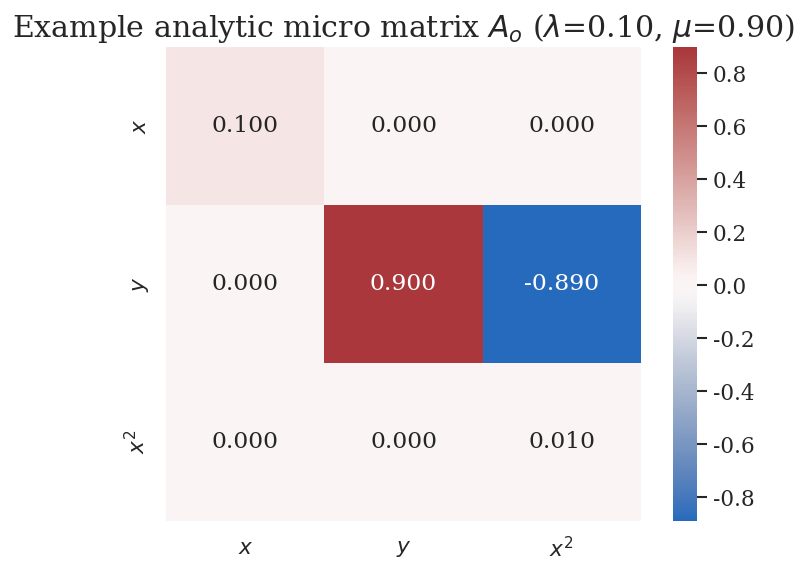

In [25]:
example_config = {
    'lam': 0.10,
    'mu': 0.90,
}

A_example = make_step_system_matrix(example_config['lam'], example_config['mu'])
display(pd.DataFrame(A_example, index=FEATURE_NAMES, columns=FEATURE_NAMES))
plot_matrix_heatmap(
    A_example,
    f'Example analytic micro matrix $A_o$ ($\lambda$={example_config["lam"]:.2f}, $\mu$={example_config["mu"]:.2f})',
    FEATURE_NAMES,
    FEATURE_NAMES,
    center=0.0,
    figsize=(6.2, 5.0),
    annot=True,
    decimals=3,
)


### 2.2 参数变化下的动力学谱结构

为了看清动力学参数如何影响主方向，我们在一组 `\lambda` 与 `\mu/\lambda` 比例扫描上考察矩阵 `A_o` 的奇异值分布。这里的图主要承担“几何直觉”的作用：它告诉我们在哪些参数区间里，主方向与次方向之间的分离更明显。


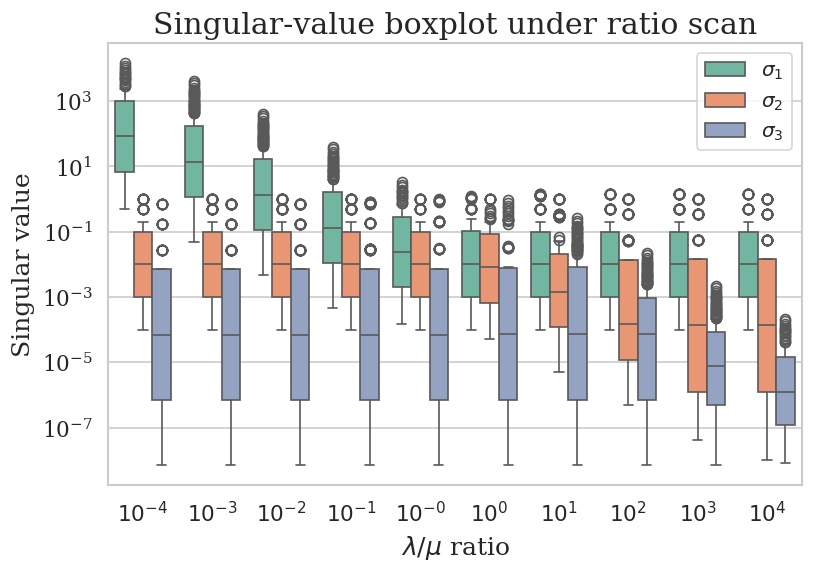

In [26]:
def generate_parameter_scan_results(lam_values=None, log_min=-4, log_max=4, n_points=120):
    if lam_values is None:
        lam_values = [0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
    ratios = 10 ** np.linspace(log_min, log_max, n_points)
    results = {}
    for lam in lam_values:
        results[lam] = {'ratios': ratios, 'sv1': [], 'sv2': [], 'sv3': []}
        for ratio in ratios:
            mu = lam / ratio
            sv = np.sort(np.linalg.svd(make_step_system_matrix(lam, mu), compute_uv=False))[::-1]
            results[lam]['sv1'].append(sv[0])
            results[lam]['sv2'].append(sv[1])
            results[lam]['sv3'].append(sv[2])
    return results, lam_values, ratios


def plot_singular_values_boxplot(results, lam_values, ratios):
    rows = []
    for lam in lam_values:
        for i, ratio in enumerate(ratios):
            lbl = f"$10^{{{np.log10(ratio):.0f}}}$"
            rows += [
                {'Ratio': lbl, 'Singular Value': results[lam]['sv1'][i], 'Type': '$\sigma_1$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv2'][i], 'Type': '$\sigma_2$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv3'][i], 'Type': '$\sigma_3$'},
            ]
    df = pd.DataFrame(rows)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='Ratio', y='Singular Value', hue='Type', palette='Set2')
    plt.yscale('log')
    plt.xlabel('$\lambda / \mu$ ratio')
    plt.ylabel('Singular value')
    plt.title('Singular-value boxplot under ratio scan')
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

scan_results, scan_lam_values, scan_ratios = generate_parameter_scan_results()
plot_singular_values_boxplot(scan_results, scan_lam_values, scan_ratios)


### 2.3 固定参数下的轨迹图与观测曲线

下面固定一组代表性参数，从多个初值生成轨迹。状态空间中的相图用于展示系统如何沿主方向收缩，而观测曲线用于说明提升到 `[x, y, x^2]` 后各通道的相对尺度和衰减速度。


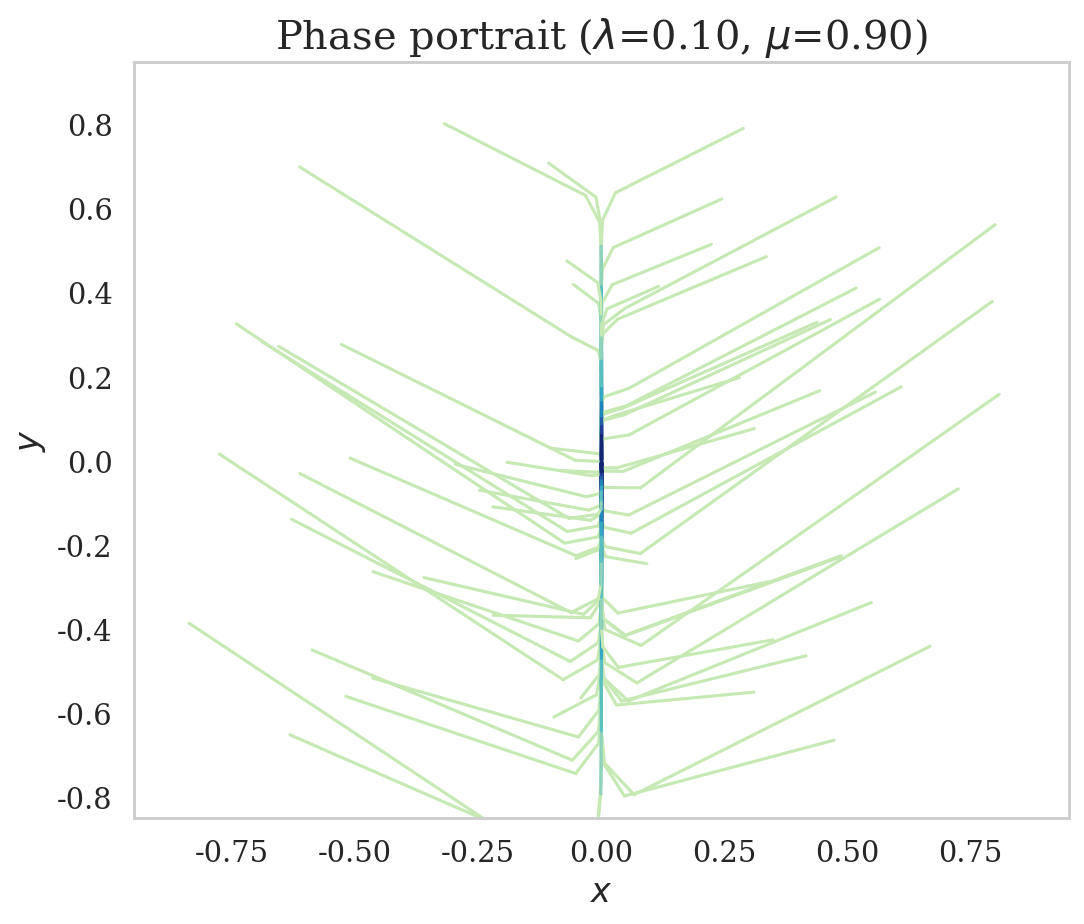

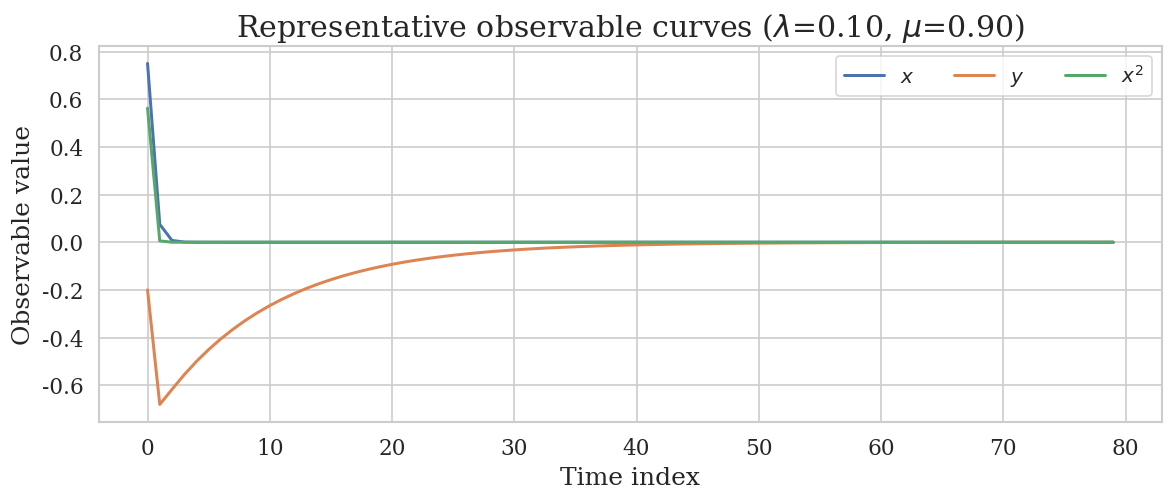

In [27]:
phase_config = {
    'lam': 0.10,
    'mu': 0.90,
    'steps': 50,
    'dt': 1.0,
    'num_samples': 60,
}

plot_phase_trajectories_like_ref(
    lam=phase_config['lam'],
    mu=phase_config['mu'],
    steps=phase_config['steps'],
    num_samples=phase_config['num_samples'],
    seed=SEED,
)

single_traj = simulate_discrete_system(
    step_map,
    [0.75, -0.20],
    steps=80,
    system_kwargs={'lam': phase_config['lam'], 'mu': phase_config['mu']},
    dt=1.0,
)['trajectories'][0]
obs_single = observable_step(single_traj, mode='default')
fig, ax = plt.subplots(figsize=(10, 4.4))
for idx, name in enumerate(FEATURE_NAMES):
    ax.plot(obs_single[:80, idx], linewidth=1.8, label=name)
ax.set_title(f'Representative observable curves ($\lambda$={phase_config["lam"]:.2f}, $\mu$={phase_config["mu"]:.2f})')
ax.set_xlabel('Time index')
ax.set_ylabel('Observable value')
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


## 3. 关于动力学参数的研究

这一部分的核心是符号推导。我们不先固定参数，而是先在符号层面写出 `A_o`、`\Sigma_o`、`\Sigma_o^{-1}` 与 `A_o^T \Sigma_o^{-1} A_o`，再在若干代表性参数下考察 `CE`、奇异值谱与粗粒化维度的变化。


### 3.1 符号矩阵与参数约束

噪声协方差取为

$$
\Sigma_o =
\begin{pmatrix}
b & 0 & c \\
0 & b & 0 \\
c & 0 & b
\end{pmatrix}.
$$

为了保证 `\Sigma_o` 半正定，通常要求 `b \ge |c|` 且 `b \ge 0`。在本 notebook 的数值实验里，我们进一步主要考虑 `b \ge c \ge 0`。动力学参数 `\lambda, \mu` 在符号讨论中不做过强限制，但在数值实验中主要选取小于 1 的稳定区间。


In [28]:
lam_sym, mu_sym, b_sym, c_sym = sp.symbols('lambda mu b c', real=True)

A_sym = sp.Matrix([
    [lam_sym, 0, 0],
    [0, mu_sym, lam_sym**2 - mu_sym],
    [0, 0, lam_sym**2],
])
Sigma_sym = sp.Matrix([
    [b_sym, 0, c_sym],
    [0, b_sym, 0],
    [c_sym, 0, b_sym],
])

sigma_det = sp.factor(Sigma_sym.det())
sigma_eigs = list(Sigma_sym.eigenvals().keys())

display_symbolic_matrix('A_o', A_sym)
display_symbolic_matrix('Sigma_o', Sigma_sym)
display(Markdown(f'`det(Sigma_o) = {sp.latex(sigma_det)}`'))
display(Markdown('`Sigma_o` 的特征值为：'))
for eig in sigma_eigs:
    display(sp.Eq(sp.Symbol('eta'), eig, evaluate=False))


**A_o**

Eq(A_o, Matrix([
[lambda,  0,              0],
[     0, mu, lambda**2 - mu],
[     0,  0,      lambda**2]]))

**Sigma_o**

Eq(Sigma_o, Matrix([
[b, 0, c],
[0, b, 0],
[c, 0, b]]))

`det(Sigma_o) = b \left(b - c\right) \left(b + c\right)`

`Sigma_o` 的特征值为：

Eq(eta, b - c)

Eq(eta, b + c)

Eq(eta, b)

### 3.2 符号推导 \Sigma_o^{-1}

先求出噪声协方差的逆矩阵。这个结果在后续的确定性结构、非简并性结构以及 `CE` 的谱计算中都会直接出现，因此是解析实验中最基础的符号对象之一。


In [29]:
Sigma_inv_sym = sp.simplify(Sigma_sym.inv())
display_symbolic_matrix('Sigma_o^{-1}', Sigma_inv_sym)


**Sigma_o^{-1}**

Eq(Sigma_o^{-1}, Matrix([
[ b/(b**2 - c**2),   0, -c/(b**2 - c**2)],
[               0, 1/b,                0],
[-c/(b**2 - c**2),   0,  b/(b**2 - c**2)]]))

### 3.3 符号推导 A_o^T \Sigma_o^{-1} A_o

下一步构造后向结构矩阵 `A_o^T \Sigma_o^{-1} A_o`。按照研究流程，这个矩阵与 `\Sigma_o^{-1}` 一起决定了 `CE` 与两步 `SVD` 中会被保留的主方向。


In [30]:
backward_sym = sp.simplify(A_sym.T * Sigma_inv_sym * A_sym)
display_symbolic_matrix('A_o^T Sigma_o^{-1} A_o', backward_sym)


**A_o^T Sigma_o^{-1} A_o**

Eq(A_o^T Sigma_o^{-1} A_o, Matrix([
[ b*lambda**2/(b**2 - c**2),                     0,                                             -c*lambda**3/(b**2 - c**2)],
[                         0,               mu**2/b,                                                  mu*(lambda**2 - mu)/b],
[-c*lambda**3/(b**2 - c**2), mu*(lambda**2 - mu)/b, (b**2*lambda**4 + (b**2 - c**2)*(lambda**2 - mu)**2)/(b*(b**2 - c**2))]]))

### 3.4 特殊情形：c = 0 的解析化简

当 `c = 0` 时，协方差矩阵变成对角形式，此时 `\Sigma_o^{-1}` 与 `A_o^T \Sigma_o^{-1} A_o` 都会显著简化。这一特殊情形会在后面的第四部分作为第一组完整流程实验单独讨论。


In [31]:
Sigma_c0_sym = sp.simplify(Sigma_sym.subs(c_sym, 0))
Sigma_inv_c0_sym = sp.simplify(Sigma_inv_sym.subs(c_sym, 0))
backward_c0_sym = sp.simplify(backward_sym.subs(c_sym, 0))

display_symbolic_matrix('Sigma_o |_{c=0}', Sigma_c0_sym)
display_symbolic_matrix('Sigma_o^{-1} |_{c=0}', Sigma_inv_c0_sym)
display_symbolic_matrix('A_o^T Sigma_o^{-1} A_o |_{c=0}', backward_c0_sym)


**Sigma_o |_{c=0}**

Eq(Sigma_o |_{c=0}, Matrix([
[b, 0, 0],
[0, b, 0],
[0, 0, b]]))

**Sigma_o^{-1} |_{c=0}**

Eq(Sigma_o^{-1} |_{c=0}, Matrix([
[1/b,   0,   0],
[  0, 1/b,   0],
[  0,   0, 1/b]]))

**A_o^T Sigma_o^{-1} A_o |_{c=0}**

Eq(A_o^T Sigma_o^{-1} A_o |_{c=0}, Matrix([
[lambda**2/b,                     0,                                   0],
[          0,               mu**2/b,               mu*(lambda**2 - mu)/b],
[          0, mu*(lambda**2 - mu)/b, (lambda**4 + (lambda**2 - mu)**2)/b]]))

### 3.5 参数代入下的数值扫描

由于完整的闭式谱表达可能较长，下面在代表性参数网格上直接代入数值，考察 `CE`、截断维度与两步 `SVD` 的谱结构。这里分别保留 `c = 0` 和 `c > 0` 两种情形，作为后面完整流程实验的前置观察。


,lam,mu,b,c,label,selected_r,CE,sv_forward_1,sv_forward_2,sv_forward_3,sv_backward_1,sv_backward_2,sv_backward_3,stage2_sv1,stage2_sv2,stage2_sv3
0,0.1,0.2,0.6,0.0,c=0,1,0.775761,1.666667,1.666667,1.666667,0.126912,0.016667,0.000088,1.283449,1.191677,1.140329
1,0.1,0.2,0.6,0.2,c>0,1,0.857520,2.500000,1.666667,1.250000,0.126924,0.018759,0.000087,1.340096,1.218740,1.100711
2,0.1,0.4,0.6,0.0,c=0,1,1.012939,1.666667,1.666667,1.666667,0.520248,0.016667,0.000085,1.418547,1.191677,1.140279
3,0.1,0.4,0.6,0.2,c>0,1,1.094680,2.500000,1.666667,1.250000,0.520258,0.018760,0.000085,1.446393,1.244333,1.103291
4,0.1,0.6,0.6,0.0,c=0,1,1.150155,1.666667,1.666667,1.666667,1.180249,0.016667,0.000085,1.541878,1.191677,1.140263
5,0.1,0.6,0.6,0.2,c>0,1,1.231893,2.500000,1.666667,1.250000,1.180259,0.018760,0.000085,1.561147,1.251493,1.104229
6,0.1,0.8,0.6,0.0,c=0,1,1.247083,1.666667,1.666667,1.666667,2.106916,0.016667,0.000084,1.656054,1.191677,1.140254
7,0.1,0.8,0.6,0.2,c>0,1,1.328820,2.500000,1.666667,1.250000,2.106926,0.018761,0.000084,1.671383,1.254567,1.104710
8,0.2,0.2,0.6,0.0,c=0,1,0.394317,1.666667,1.666667,1.666667,0.110390,0.066667,0.001610,1.274066,1.244666,1.153744
9,0.2,0.2,0.6,0.2,c>0,1,0.476996,2.500000,1.666667,1.250000,0.110807,0.074921,0.001606,1.356599,1.240185,1.121791


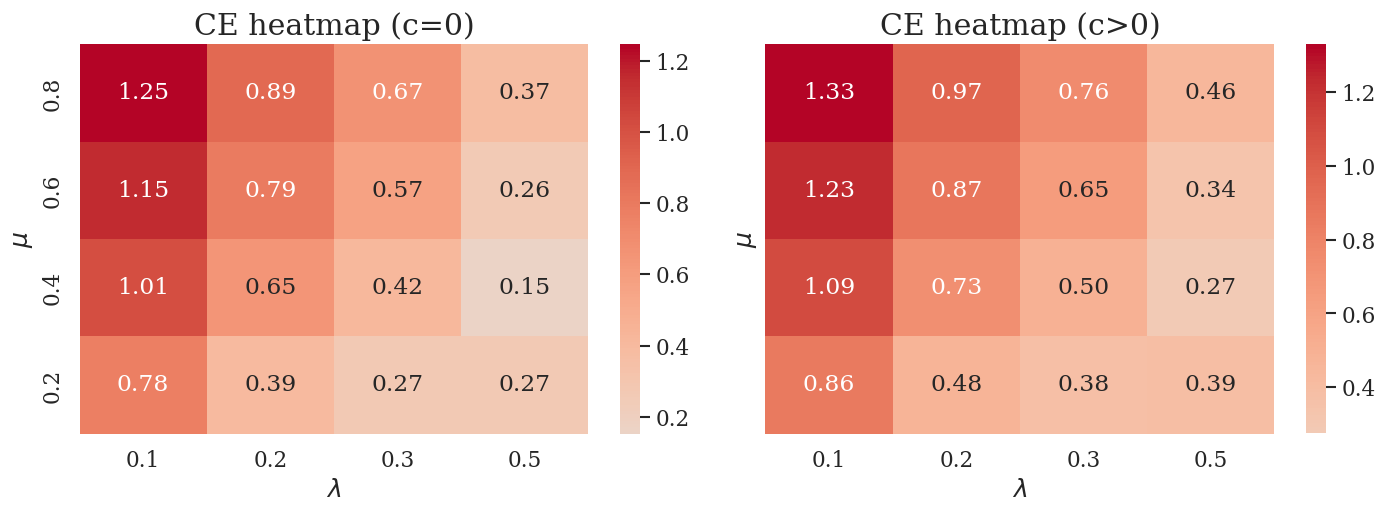

In [32]:
parameter_scan_configs = []
for lam in [0.10, 0.20, 0.30, 0.50]:
    for mu in [0.20, 0.40, 0.60, 0.80]:
        parameter_scan_configs.append({'lam': lam, 'mu': mu, 'b': 0.60, 'c': 0.00, 'label': 'c=0'})
        parameter_scan_configs.append({'lam': lam, 'mu': mu, 'b': 0.60, 'c': 0.20, 'label': 'c>0'})

parameter_rows = []
for config in parameter_scan_configs:
    sigma_valid = check_analytic_sigma_validity(config['b'], config['c'], allow_singular=True)
    if not sigma_valid['is_valid']:
        continue
    A_num = make_step_system_matrix(config['lam'], config['mu'])
    Sigma_num = make_analytic_sigma_matrix(config['b'], config['c'])
    metrics_num = compute_gis_metrics(A_num, Sigma_num, alpha=DEFAULT_ALPHA, eps=DEFAULT_EPS)
    ce_num = compute_ce_from_gis_metrics(metrics_num, r_eps=None, eps=DEFAULT_EPS)
    w_num = build_w_from_svd(A_num, Sigma_num, r=ce_num['selected_r'], alpha=DEFAULT_ALPHA, eps=DEFAULT_EPS, mode='two_stage')
    parameter_rows.append({
        **config,
        'selected_r': ce_num['selected_r'],
        'CE': ce_num['CE'],
        'sv_forward_1': metrics_num['sv_forward'][0],
        'sv_forward_2': metrics_num['sv_forward'][1],
        'sv_forward_3': metrics_num['sv_forward'][2],
        'sv_backward_1': metrics_num['sv_backward'][0],
        'sv_backward_2': metrics_num['sv_backward'][1],
        'sv_backward_3': metrics_num['sv_backward'][2],
        'stage2_sv1': w_num['sv_info']['sv_stage2'][0],
        'stage2_sv2': w_num['sv_info']['sv_stage2'][1],
        'stage2_sv3': w_num['sv_info']['sv_stage2'][2],
    })

parameter_scan_df = pd.DataFrame(parameter_rows)
display(parameter_scan_df.head(12))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, label in zip(axes, ['c=0', 'c>0']):
    subset = parameter_scan_df[parameter_scan_df['label'] == label]
    pivot = subset.pivot(index='mu', columns='lam', values='CE').sort_index(ascending=False)
    sns.heatmap(pivot, ax=ax, cmap='coolwarm', center=0.0, annot=True, fmt='.2f')
    ax.set_title(f'CE heatmap ({label})')
    ax.set_xlabel('$\\lambda$')
    ax.set_ylabel('$\\mu$')
plt.tight_layout()
plt.show()


## 4. 关于动力学确定参数下，`c = 0` 的全流程实验

这一部分严格对应附录 D 的主流程，并固定参数走一遍 `c = 0` 的完整实验。这里 `b > 0`、`c = 0`，因此噪声存在但没有交叉相关项，可以视为相关噪声引入之前的基线情形。


In [33]:
pipeline_c0_config = {
    'experiment_name': 'ana_exp_gisce_c0',
    'lam': 0.30,
    'mu': 0.70,
    'b': 0.60,
    'c': 0.00,
    'initial_state': np.array([0.75, -0.20]),
    'steps': 220,
    'dt': 1.0,
    'tau': 1,
    'alpha': DEFAULT_ALPHA,
    'eps': DEFAULT_EPS,
    'horizons': (1, 3, 5),
}

pipeline_c0_config


{'experiment_name': 'ana_exp_gisce_c0',
 'lam': 0.3,
 'mu': 0.7,
 'b': 0.6,
 'c': 0.0,
 'initial_state': array([ 0.75, -0.2 ]),
 'steps': 220,
 'dt': 1.0,
 'tau': 1,
 'alpha': 1.0,
 'eps': 1e-10,
 'horizons': (1, 3, 5)}

### 4.1 Step 1 生成状态轨迹

附录 D 的第一步是生成底层状态轨迹。这里我们使用已知的 `step_map`，给定 `\lambda` 与 `\mu` 后直接从一个初值出发生成状态序列 `\{\mathbf{x}_t\}`。


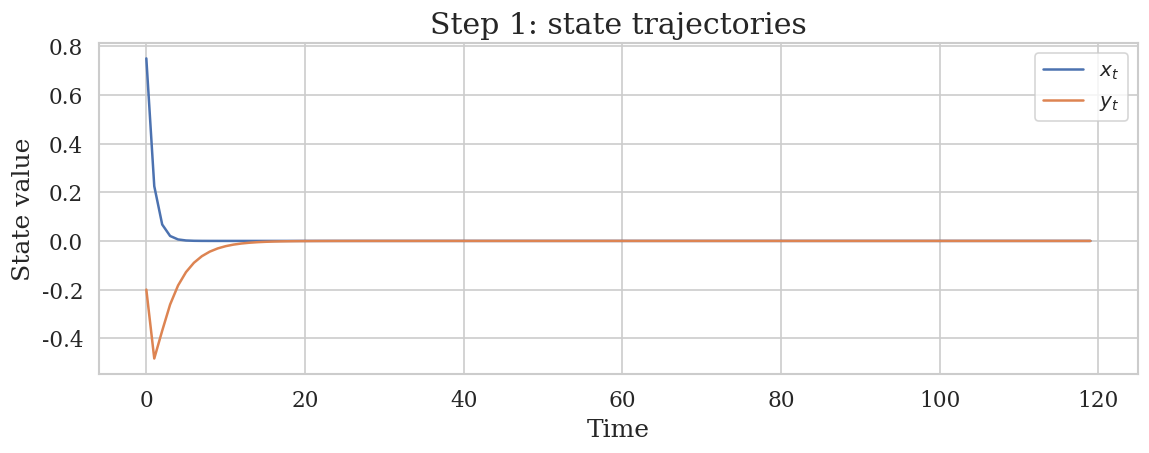

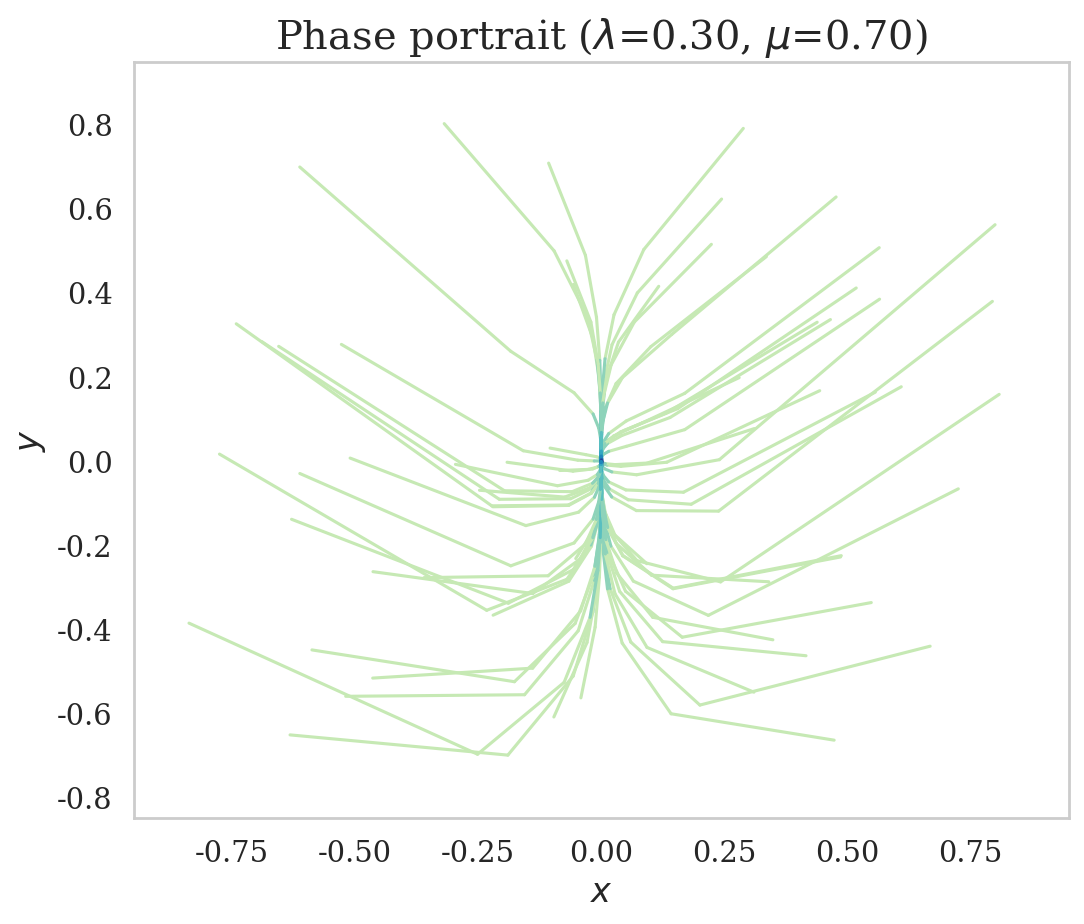

In [34]:
sim_c0 = simulate_discrete_system(
    step_map,
    pipeline_c0_config['initial_state'],
    steps=pipeline_c0_config['steps'],
    system_kwargs={'lam': pipeline_c0_config['lam'], 'mu': pipeline_c0_config['mu']},
    dt=pipeline_c0_config['dt'],
)
xy_c0 = sim_c0['trajectories'][0]
time_c0 = sim_c0['time_grid']

fig, ax = plt.subplots(figsize=(9.8, 4.0))
ax.plot(time_c0[:120], xy_c0[:120, 0], label='$x_t$')
ax.plot(time_c0[:120], xy_c0[:120, 1], label='$y_t$')
ax.set_title('Step 1: state trajectories')
ax.set_xlabel('Time')
ax.set_ylabel('State value')
ax.legend()
plt.tight_layout()
plt.show()

plot_phase_trajectories_like_ref(
    lam=pipeline_c0_config['lam'],
    mu=pipeline_c0_config['mu'],
    steps=50,
    num_samples=60,
    seed=SEED,
)

A_c0_micro = make_step_system_matrix(pipeline_c0_config['lam'], pipeline_c0_config['mu'])
Sigma_c0_micro = make_analytic_sigma_matrix(pipeline_c0_config['b'], pipeline_c0_config['c'])


### 4.2 Step 2 构造观测变量

第二步是通过观测函数将状态层映射到观测层。这里固定使用 `g(x, y) = [x, y, x^2]^\top`，得到观测序列 `\{\mathbf{o}_t\}`。


In [35]:
obs_clean_c0 = observable_step(xy_c0, mode='default')
obs_c0 = simulate_noisy_observation_series(
    A_c0_micro,
    Sigma_c0_micro,
    obs_clean_c0[0],
    steps=len(xy_c0) - 1,
    random_state=SEED,
)
X_now_c0, X_next_c0 = prepare_time_pairs(obs_c0, tau=pipeline_c0_config['tau'], burn_in=0, stride=1)

display(pd.DataFrame(obs_c0[:5], columns=FEATURE_NAMES))
print('Noisy observation shape:', obs_c0.shape)
print('Paired shape:', X_now_c0.shape, X_next_c0.shape)


,$x$,$y$,$x^2$
0,0.750000,-0.200000,0.562500
1,0.461033,-1.288693,0.631922
2,0.866868,-2.798823,-0.951791
3,0.359085,-1.623544,-0.098675
4,-0.553039,-0.395110,0.593594


Noisy observation shape: (221, 3)
Paired shape: (220, 3) (220, 3)


### 4.3 Step 3 给定微观层真值 A_o 与 \Sigma_o

第三步不再进行数据拟合，而是直接给出真值动力学矩阵与真值协方差矩阵。对于本部分，`c = 0`，因此 `\Sigma_o` 只有对角噪声而没有相关项。


参数合法：协方差矩阵为半正定。


,$x$,$y$,$x^2$
$x$,0.3,0.0,0.00
$y$,0.0,0.7,-0.61
$x^2$,0.0,0.0,0.09


,$x$,$y$,$x^2$
$x$,0.6,0.0,0.0
$y$,0.0,0.6,0.0
$x^2$,0.0,0.0,0.6


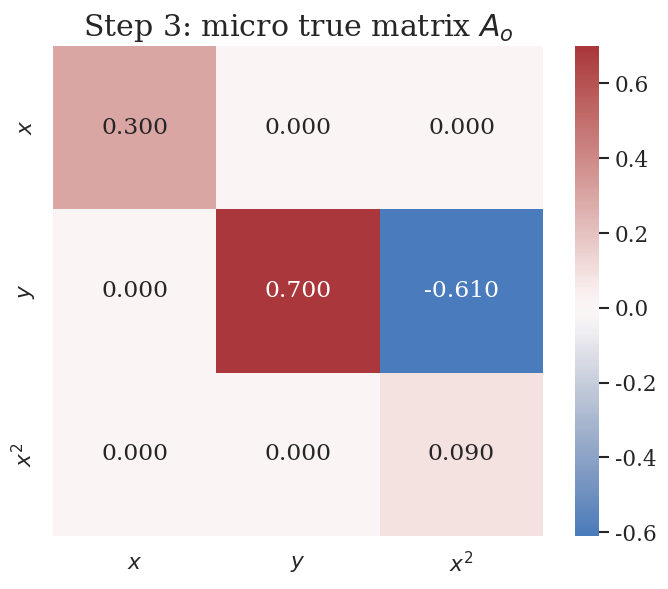

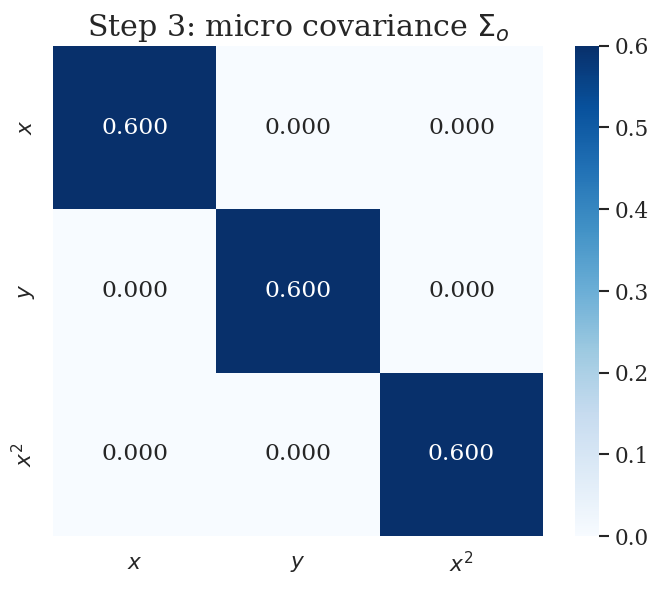

In [36]:
A_c0_micro = make_step_system_matrix(pipeline_c0_config['lam'], pipeline_c0_config['mu'])
Sigma_c0_micro = make_analytic_sigma_matrix(pipeline_c0_config['b'], pipeline_c0_config['c'])
validity_c0 = check_analytic_sigma_validity(pipeline_c0_config['b'], pipeline_c0_config['c'], allow_singular=True)

print(validity_c0['message'])
display(pd.DataFrame(A_c0_micro, index=FEATURE_NAMES, columns=FEATURE_NAMES))
display(pd.DataFrame(Sigma_c0_micro, index=FEATURE_NAMES, columns=FEATURE_NAMES))
plot_matrix_heatmap(A_c0_micro, 'Step 3: micro true matrix $A_o$', FEATURE_NAMES, FEATURE_NAMES, center=0.0)
plot_matrix_heatmap(Sigma_c0_micro, 'Step 3: micro covariance $\\Sigma_o$', FEATURE_NAMES, FEATURE_NAMES, center=0.0)


### 4.4 Step 4 微观层预测

第四步是在微观层上使用真值矩阵 `A_o` 做单步和多步预测。由于这一部分是已知动力学实验，预测的目的不是检验拟合精度，而是展示在真实解析结构下观测层的演化误差与时间尺度关系。


benchmark for 100-step recursive rollout: 0.0010 s
selected recursive rollout steps: 220
recursive rollout MSE: 0.873798


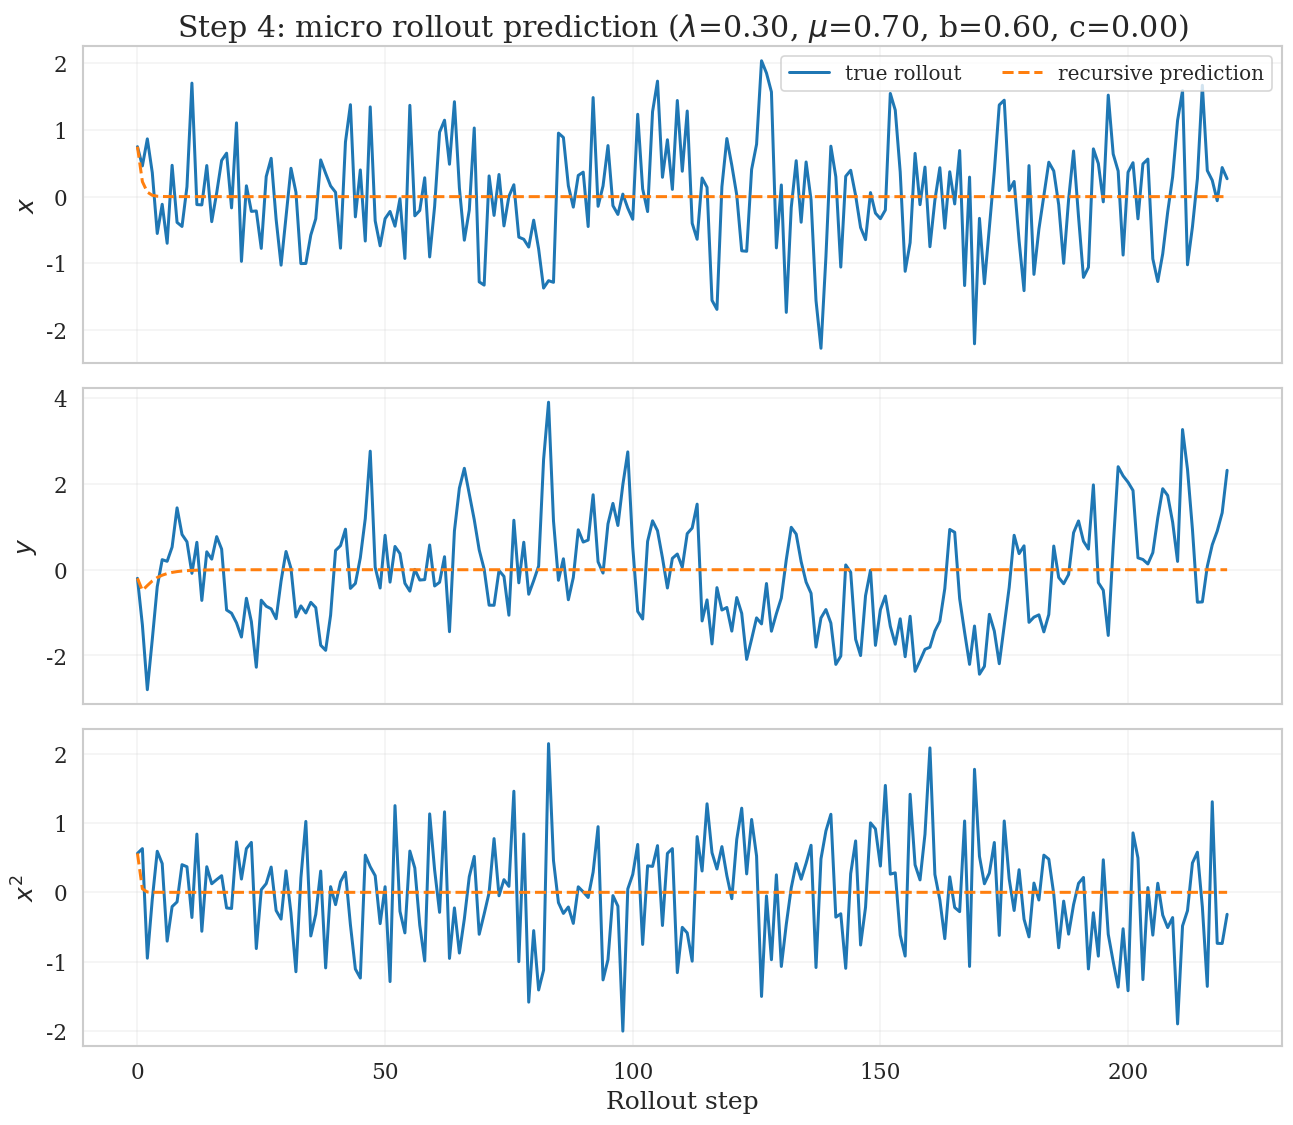

In [37]:
errors_c0_micro = compute_prediction_errors(
    A_c0_micro,
    obs_c0,
    tau=pipeline_c0_config['tau'],
    horizons=pipeline_c0_config['horizons'],
)

rollout_steps_c0, benchmark_elapsed_c0 = choose_rollout_length(
    A_c0_micro,
    obs_c0[0],
    target_seconds=10.0,
    base_steps=100,
    max_steps=500,
    min_steps=50,
)
rollout_steps_c0 = min(rollout_steps_c0, len(obs_c0) - 1)
rollout_pred_c0 = rollout_linear_gis(A_c0_micro, obs_c0[0], rollout_steps_c0)
true_rollout_c0 = obs_c0[:rollout_steps_c0 + 1]
rollout_mse_c0 = float(np.mean((true_rollout_c0 - rollout_pred_c0) ** 2))

print(f'benchmark for 100-step recursive rollout: {benchmark_elapsed_c0:.4f} s')
print(f'selected recursive rollout steps: {rollout_steps_c0}')
print(f'recursive rollout MSE: {rollout_mse_c0:.6f}')
plot_rollout_prediction(
    true_rollout_c0,
    rollout_pred_c0,
    FEATURE_NAMES,
    f'Step 4: micro rollout prediction ($\lambda$={pipeline_c0_config["lam"]:.2f}, $\mu$={pipeline_c0_config["mu"]:.2f}, b={pipeline_c0_config["b"]:.2f}, c={pipeline_c0_config["c"]:.2f})',
    n_plot=rollout_steps_c0 + 1,
)


### 4.5 Step 5 提取谱并直接计算 CE

第五步是本 notebook 的理论核心。我们从真值 `A_o` 与 `\Sigma_o` 出发，计算 `\Sigma_o^{-1}` 和 `A_o^T \Sigma_o^{-1} A_o` 的谱，再按研究流程 2.0 的公式直接得到 `CE`。此时 `CE` 完全由微观层谱信息和截断维度决定，不需要重新拟合宏观层矩阵。


CE = 0.625353


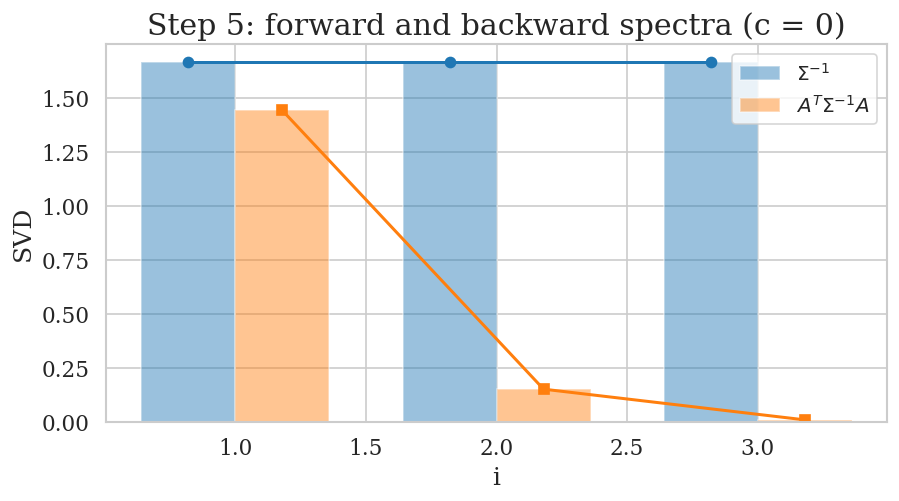

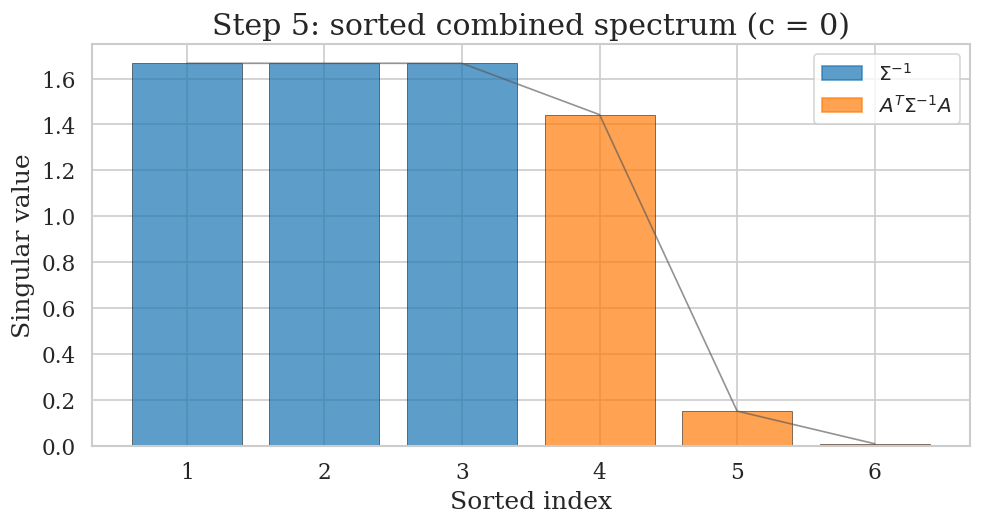

In [38]:
metrics_c0_micro = compute_gis_metrics(A_c0_micro, Sigma_c0_micro, alpha=pipeline_c0_config['alpha'], eps=pipeline_c0_config['eps'])
ce_c0 = compute_ce_from_gis_metrics(metrics_c0_micro, r_eps=None, eps=pipeline_c0_config['eps'])

print(f"CE = {ce_c0['CE']:.6f}")
plot_dual_gis_spectrum(metrics_c0_micro['sv_forward'], metrics_c0_micro['sv_backward'], 'Step 5: forward and backward spectra (c = 0)')
plot_sorted_combined_gis_spectrum(
    metrics_c0_micro['sv_forward'],
    metrics_c0_micro['sv_backward'],
    'Step 5: sorted combined spectrum (c = 0)',
)


### 4.6 Step 6 两步 SVD 构造粗粒化矩阵 W

第六步根据真值微观层结构做两步 `SVD`，得到粗粒化矩阵 `W`。在这里，`W` 的维度由上一步得到的 `r_\epsilon` 决定，而不是由宏观拟合误差来回调参。


CE2 = 0.229246


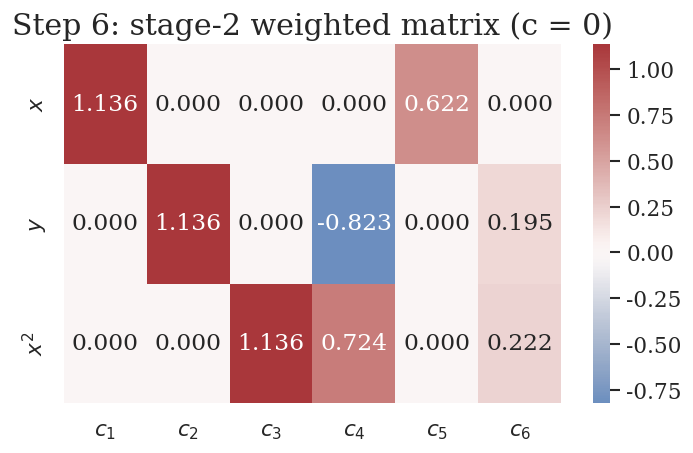

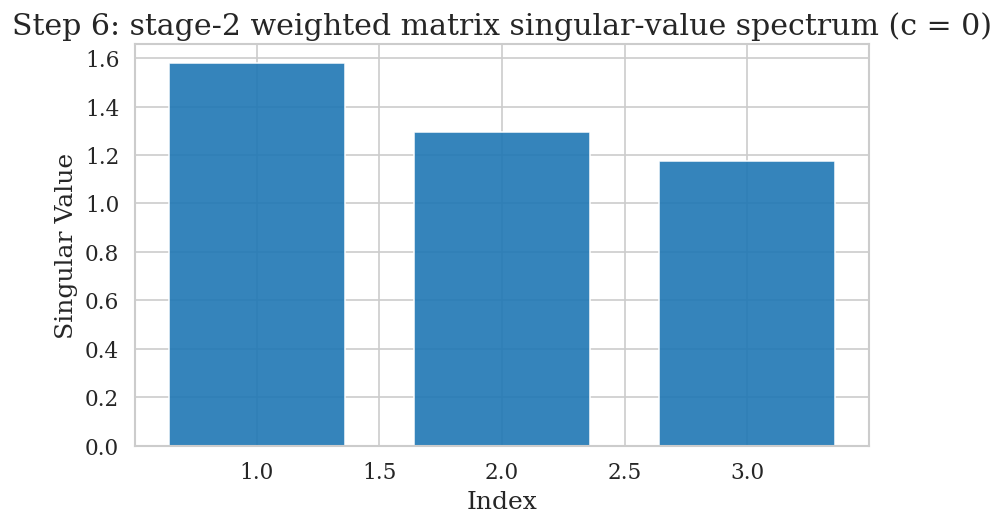

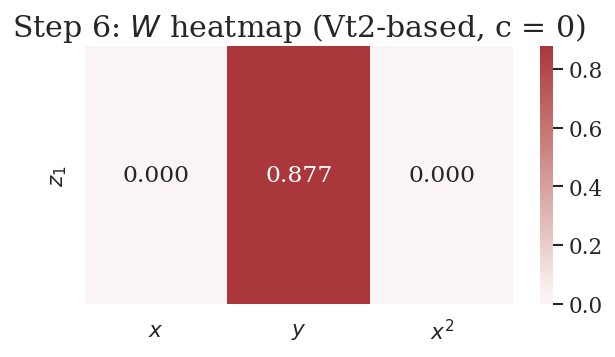

[[0.         0.87705802 0.        ]]


In [39]:
W_pack_c0 = build_w_from_svd(
    A_c0_micro,
    Sigma_c0_micro,
    r=ce_c0['selected_r'],
    alpha=pipeline_c0_config['alpha'],
    eps=pipeline_c0_config['eps'],
    mode='two_stage',
)
weighted_matrix_c0 = np.asarray(W_pack_c0['basis_info']['weighted_matrix'], dtype=float)

# CHANGED: use Vt2[:, :r] instead of U2[:, :r], then transpose it back to the
# usual row-wise W shape. To restore the previous version, replace basis_c0 =
# Vt2_c0[:, :W_pack_c0['r']] with basis_c0 = U2_c0[:, :W_pack_c0['r']].
U2_c0, stage2_sv_c0, Vt2_c0 = np.linalg.svd(weighted_matrix_c0, full_matrices=False)
basis_c0 = Vt2_c0[:, :W_pack_c0['r']]
W_c0 = basis_c0.T
macro_names_c0 = [f'$z_{i+1}$' for i in range(W_pack_c0['r'])]
ce2_c0 = np.mean(stage2_sv_c0[:W_pack_c0['r']]) - np.mean(stage2_sv_c0)

print(f"CE2 = {ce2_c0:.6f}")
plot_matrix_heatmap(
    weighted_matrix_c0,
    'Step 6: stage-2 weighted matrix (c = 0)',
    FEATURE_NAMES,
    [f'$c_{i+1}$' for i in range(weighted_matrix_c0.shape[1])],
    center=0.0,
    figsize=(6.0, 4.0),
    annot=True,
    decimals=3,
)
plot_blue_singular_value_bars(stage2_sv_c0, 'Step 6: stage-2 weighted matrix singular-value spectrum (c = 0)')
plot_matrix_heatmap(
    W_c0,
    'Step 6: $W$ heatmap (Vt2-based, c = 0)',
    macro_names_c0,
    FEATURE_NAMES,
    center=0.0,
    figsize=(5.2, 3.2),
    cmap='vlag',
    annot=True,
    decimals=3,
)
print(W_c0)


### 4.7 Step 7 构造宏观变量

第七步只负责由粗粒化矩阵构造宏观变量，也就是根据

$$
\mathbf{z}_t = W \mathbf{o}_t
$$

得到宏观时间序列。按照附录 D 的流程，这一步先完成变量构造本身，数据对比图留到下一步统一展示。


In [40]:
z_c0 = apply_coarse_graining(W_c0, obs_c0)
Z_now_c0, Z_next_c0 = prepare_time_pairs(z_c0, tau=pipeline_c0_config['tau'], burn_in=0, stride=1)

print('Macro series shape:', z_c0.shape)
display(pd.DataFrame(z_c0[:5], columns=macro_names_c0))


Macro series shape: (221, 1)


,$z_1$
0,-0.175412
1,-1.130259
2,-2.454730
3,-1.423942
4,-0.346535


### 4.8 Step 8 数据对比图

第八步集中展示数据对比图。这里主要看两类对比：

1. 宏观变量与观测变量的趋势对比。
2. 宏观变量与原始状态变量的趋势对比。

这一部分不再额外展示宏观层谱图，重点放在粗粒化后保留下来的时间结构。


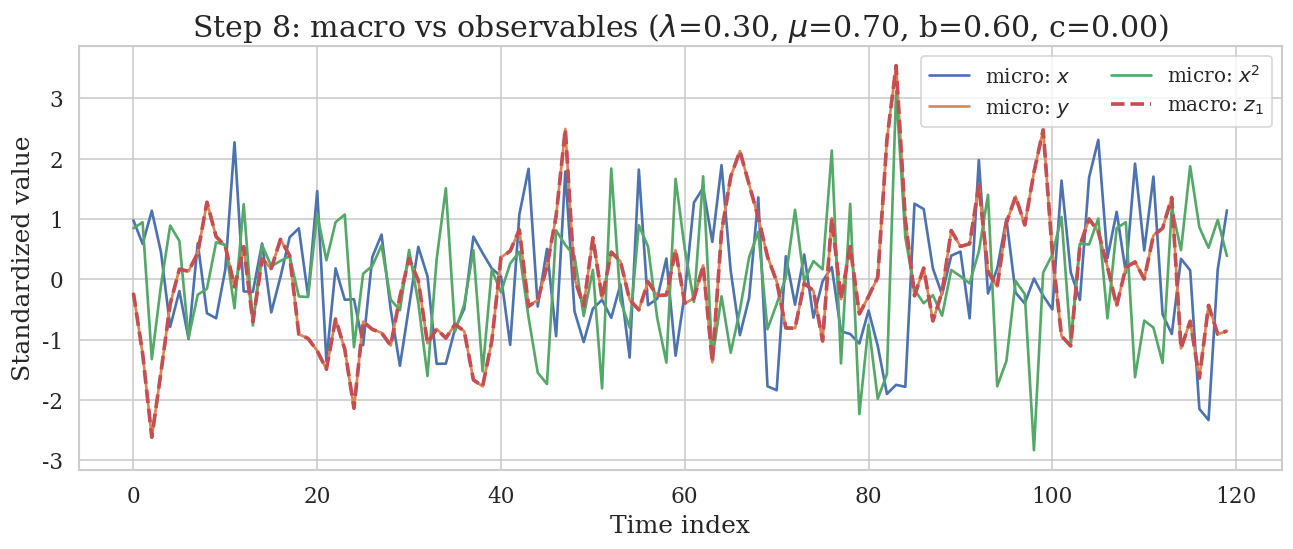

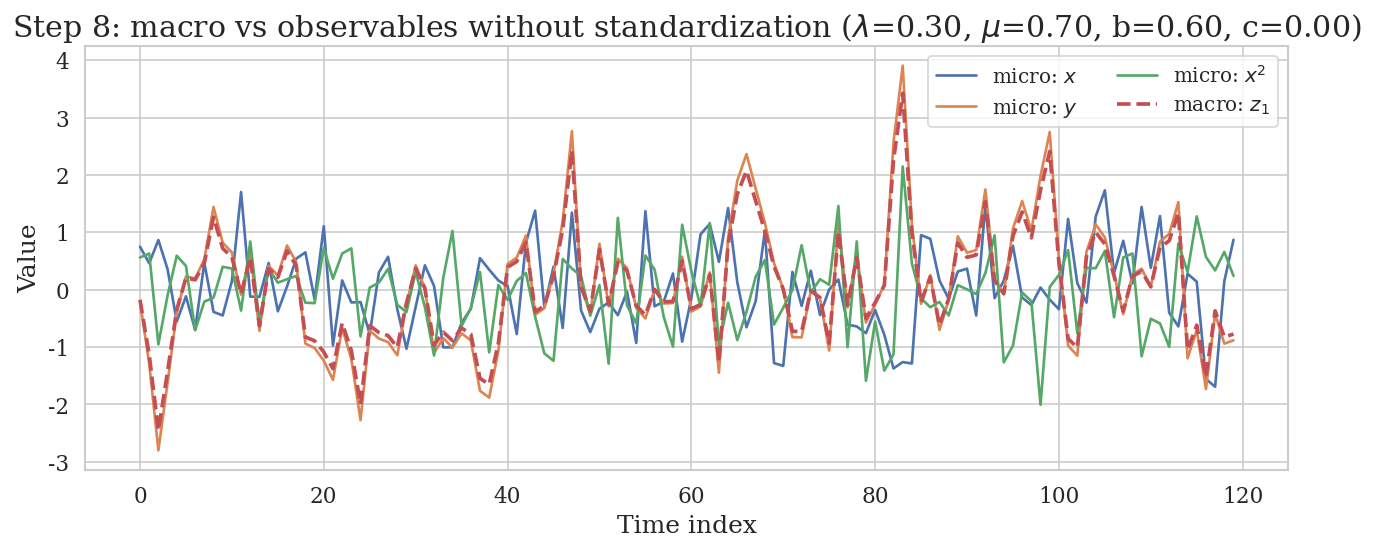

In [41]:
macro_pack_c0 = compute_macro_true_matrices(A_c0_micro, Sigma_c0_micro, W_c0)
A_c0_macro = macro_pack_c0['A_macro']
Sigma_c0_macro = macro_pack_c0['Sigma_macro']
errors_c0_macro = {}

plot_micro_macro_curves(
    obs_c0,
    z_c0,
    FEATURE_NAMES,
    macro_names_c0,
    f'Step 8: macro vs observables ($\lambda$={pipeline_c0_config["lam"]:.2f}, $\mu$={pipeline_c0_config["mu"]:.2f}, b={pipeline_c0_config["b"]:.2f}, c={pipeline_c0_config["c"]:.2f})',
    n_plot=120,
)
plot_micro_macro_curves(
    obs_c0,
    z_c0,
    FEATURE_NAMES,
    macro_names_c0,
    f'Step 8: macro vs observables without standardization ($\lambda$={pipeline_c0_config["lam"]:.2f}, $\mu$={pipeline_c0_config["mu"]:.2f}, b={pipeline_c0_config["b"]:.2f}, c={pipeline_c0_config["c"]:.2f})',
    n_plot=120,
    standardize=False,
)


### 4.9 Step 9 结果汇总与结论

第九步汇总 `CE`、截断维度 `r_\epsilon`、粗粒化矩阵 `W`、宏微观预测误差和关键谱量，并给出这一组参数下的简要结论。


In [42]:
summary_c0 = summarize_pipeline_for_display(
    label='c=0',
    config=pipeline_c0_config,
    metrics_micro=metrics_c0_micro,
    ce_result=ce_c0,
    w_result=W_pack_c0,
    macro_pack=macro_pack_c0,
    errors_micro=errors_c0_micro,
    errors_macro=errors_c0_macro,
)
display(summary_c0)


,label,lam,mu,b,c,selected_r,CE,gamma_hat,gamma_hat_eps,micro_J_alpha,micro_D,micro_N,stage2_sv1,stage2_sv2,micro_E1,macro_E1,micro_dim,macro_dim
0,c=0,0.3,0.7,0.6,0.0,1,0.625353,-0.406019,0.219334,-0.406019,1.532477,-6.40471,1.578644,1.295489,1.719372,None,3,1


## 5. 关于动力学确定参数下，`c > 0` 的全流程实验

这一部分与第四部分保持相同的流程顺序，只把噪声结构改成 `c > 0`。这样做的目的是单独考察交叉相关噪声会如何改变 `CE`、主方向谱、粗粒化矩阵以及宏观层的表达效果。


In [43]:
pipeline_cpos_config = {
    'experiment_name': 'ana_exp_gisce_cpos',
    'lam': 0.1,
    'mu': 2,
    'b': 0.5,
    'c': 0.005,
    'initial_state': np.array([0.75, -0.20]),
    'steps': 200,
    'dt': 1.0,
    'tau': 1,
    'alpha': DEFAULT_ALPHA,
    'eps': DEFAULT_EPS,
    'horizons': (1, 3, 5),
}

pipeline_cpos_config


{'experiment_name': 'ana_exp_gisce_cpos',
 'lam': 0.1,
 'mu': 2,
 'b': 0.5,
 'c': 0.005,
 'initial_state': array([ 0.75, -0.2 ]),
 'steps': 200,
 'dt': 1.0,
 'tau': 1,
 'alpha': 1.0,
 'eps': 1e-10,
 'horizons': (1, 3, 5)}

### 5.1 Step 1 生成状态轨迹

这一部分沿用与第四部分相同的底层动力学，只改变噪声结构，因此第一步生成的状态轨迹与第四部分保持一致，便于后面对比。


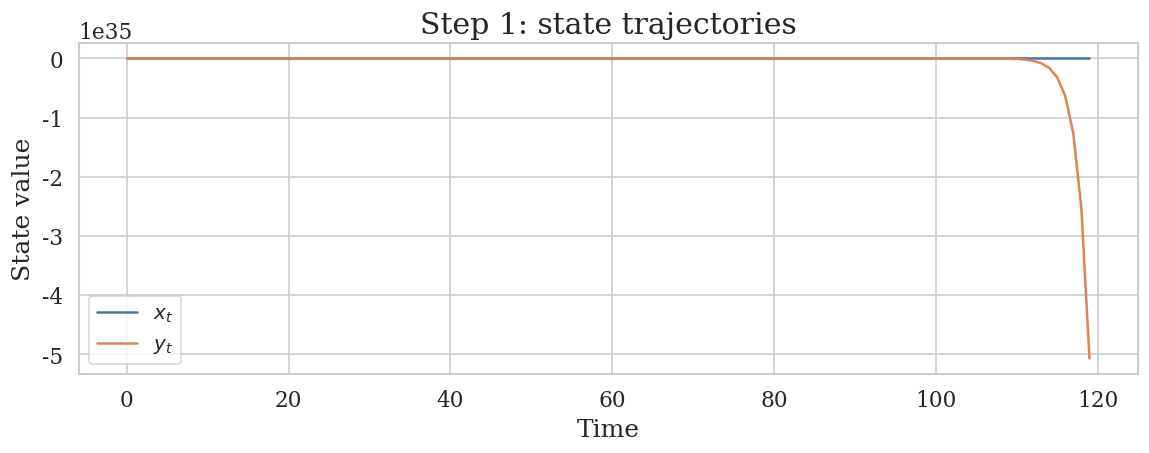

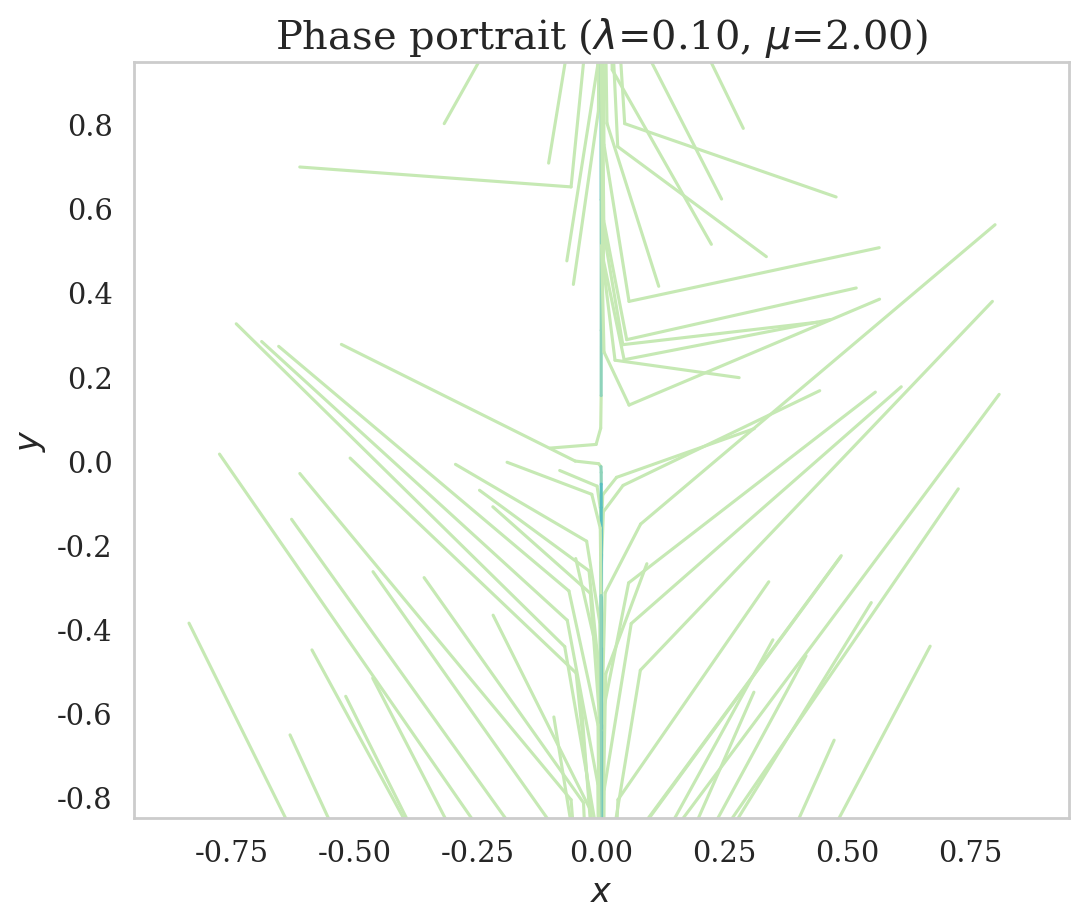

In [44]:
sim_cpos = simulate_discrete_system(
    step_map,
    pipeline_cpos_config['initial_state'],
    steps=pipeline_cpos_config['steps'],
    system_kwargs={'lam': pipeline_cpos_config['lam'], 'mu': pipeline_cpos_config['mu']},
    dt=pipeline_cpos_config['dt'],
)
xy_cpos = sim_cpos['trajectories'][0]
time_cpos = sim_cpos['time_grid']

fig, ax = plt.subplots(figsize=(9.8, 4.0))
ax.plot(time_cpos[:120], xy_cpos[:120, 0], label='$x_t$')
ax.plot(time_cpos[:120], xy_cpos[:120, 1], label='$y_t$')
ax.set_title('Step 1: state trajectories')
ax.set_xlabel('Time')
ax.set_ylabel('State value')
ax.legend()
plt.tight_layout()
plt.show()

plot_phase_trajectories_like_ref(
    lam=pipeline_cpos_config['lam'],
    mu=pipeline_cpos_config['mu'],
    steps=50,
    num_samples=60,
    seed=SEED,
)

A_cpos_micro = make_step_system_matrix(pipeline_cpos_config['lam'], pipeline_cpos_config['mu'])
Sigma_cpos_micro = make_analytic_sigma_matrix(pipeline_cpos_config['b'], pipeline_cpos_config['c'])


### 5.2 Step 2 构造观测变量

第二步仍然使用同一个观测函数 `g(x, y) = [x, y, x^2]^\top`，因此变化只来自噪声协方差结构本身。


In [45]:
obs_clean_cpos = observable_step(xy_cpos, mode='default')
obs_cpos = simulate_noisy_observation_series(
    A_cpos_micro,
    Sigma_cpos_micro,
    obs_clean_cpos[0],
    steps=len(xy_cpos) - 1,
    random_state=SEED,
)
X_now_cpos, X_next_cpos = prepare_time_pairs(obs_cpos, tau=pipeline_cpos_config['tau'], burn_in=0, stride=1)

display(pd.DataFrame(obs_cpos[:5], columns=FEATURE_NAMES))
print('Noisy observation shape:', obs_cpos.shape)
print('Paired shape:', X_now_cpos.shape, X_next_cpos.shape)


,$x$,$y$,$x^2$
0,0.750000,-0.200000,0.562500
1,0.295226,-0.783995,-0.520838
2,-1.090931,0.848068,0.169990
3,-0.181691,1.581473,-0.054181
4,0.797427,2.648938,0.041161


Noisy observation shape: (201, 3)
Paired shape: (200, 3) (200, 3)


### 5.3 Step 3 给定微观层真值 A_o 与 \Sigma_o

第三步将协方差矩阵改成带相关项的形式。此时 `c > 0`，表示第 1 与第 3 个观测通道之间存在结构化交叉噪声。


参数合法：协方差矩阵为半正定。


,$x$,$y$,$x^2$
$x$,0.1,0.0,0.00
$y$,0.0,2.0,-1.99
$x^2$,0.0,0.0,0.01


,$x$,$y$,$x^2$
$x$,0.500,0.0,0.005
$y$,0.000,0.5,0.000
$x^2$,0.005,0.0,0.500


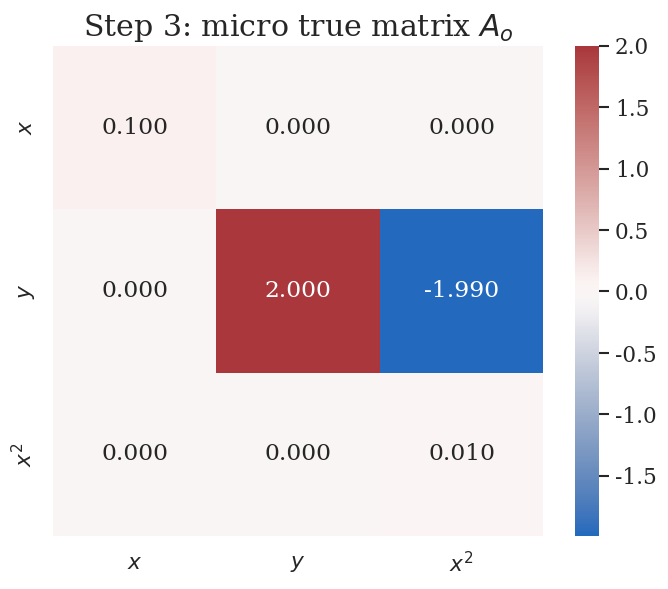

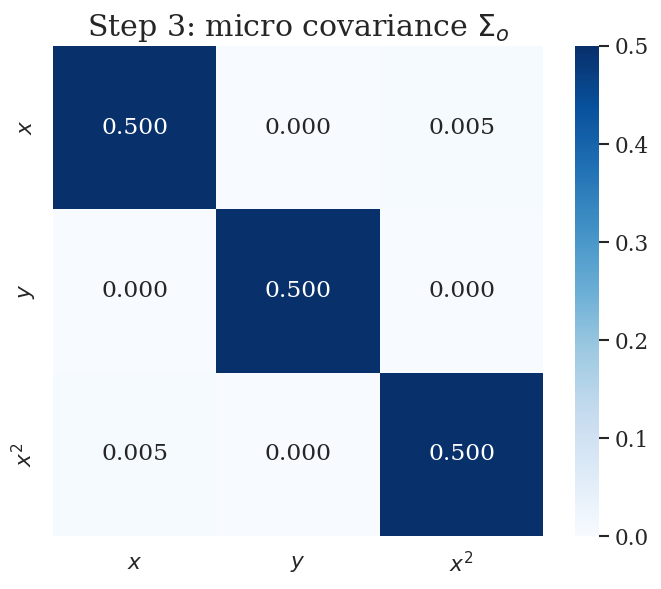

In [46]:
A_cpos_micro = make_step_system_matrix(pipeline_cpos_config['lam'], pipeline_cpos_config['mu'])
Sigma_cpos_micro = make_analytic_sigma_matrix(pipeline_cpos_config['b'], pipeline_cpos_config['c'])
validity_cpos = check_analytic_sigma_validity(pipeline_cpos_config['b'], pipeline_cpos_config['c'], allow_singular=True)

print(validity_cpos['message'])
display(pd.DataFrame(A_cpos_micro, index=FEATURE_NAMES, columns=FEATURE_NAMES))
display(pd.DataFrame(Sigma_cpos_micro, index=FEATURE_NAMES, columns=FEATURE_NAMES))
plot_matrix_heatmap(A_cpos_micro, 'Step 3: micro true matrix $A_o$', FEATURE_NAMES, FEATURE_NAMES, center=0.0)
plot_matrix_heatmap(Sigma_cpos_micro, 'Step 3: micro covariance $\\Sigma_o$', FEATURE_NAMES, FEATURE_NAMES, center=0.0)


### 5.4 Step 4 微观层预测

第四步保持相同的真值预测逻辑，用于和 `c = 0` 情形比较交叉相关噪声是否改变了不同时间尺度上的误差表现。


benchmark for 100-step recursive rollout: 0.0010 s
selected recursive rollout steps: 200
recursive rollout MSE: 4520373538626378460001349633127808606313899388603985127468569890583581739189311547777962657028683826506046728138915840.000000


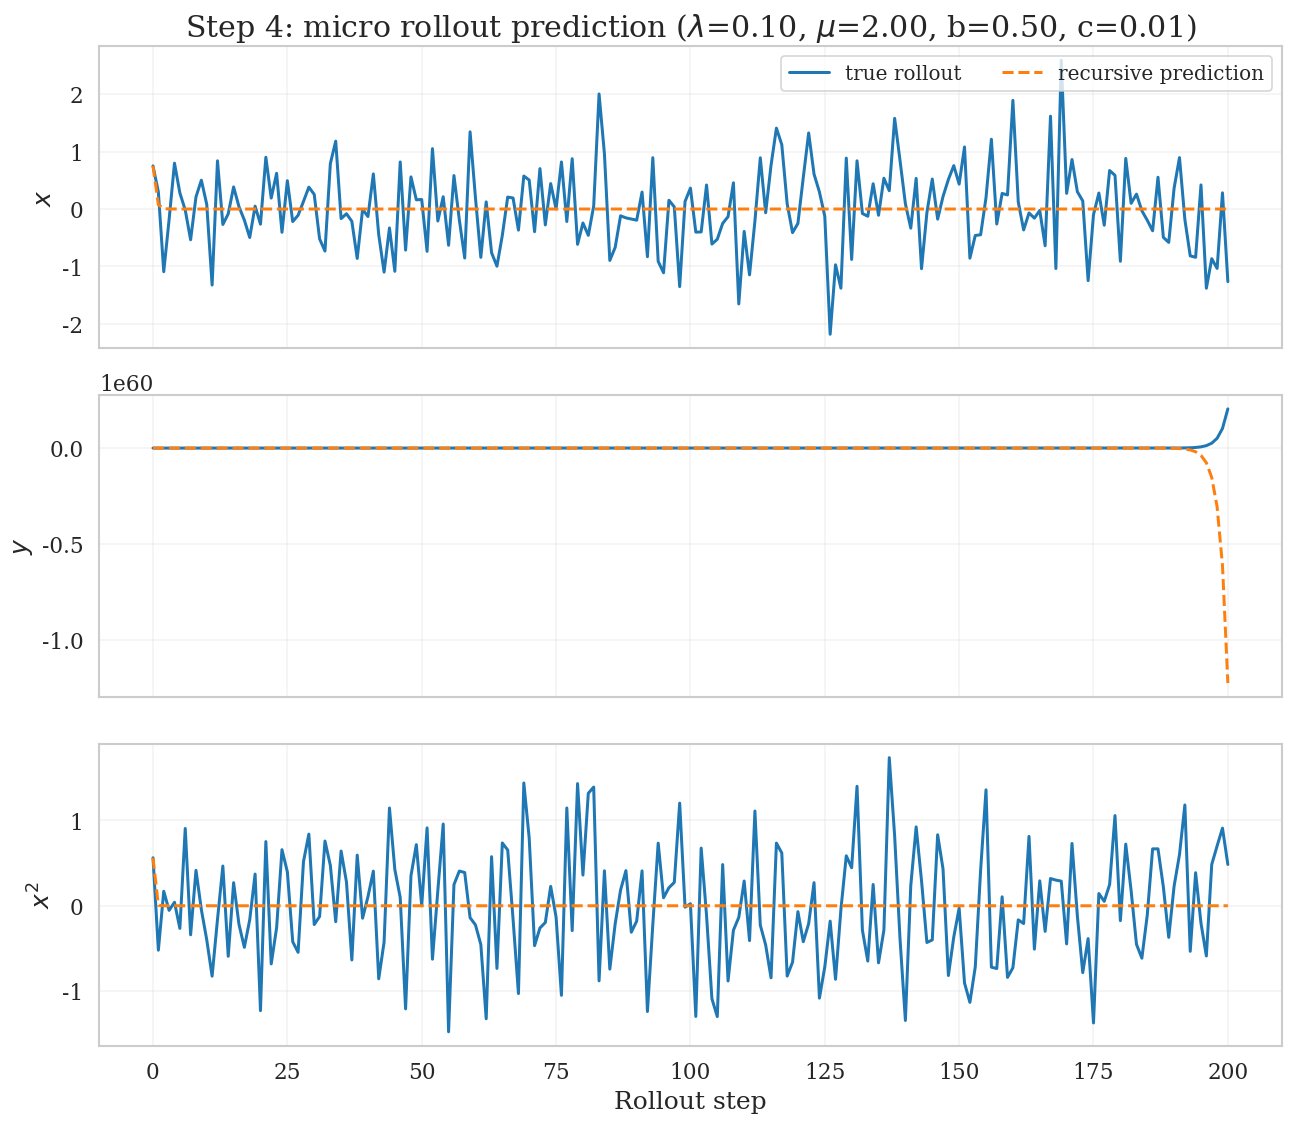

In [47]:
errors_cpos_micro = compute_prediction_errors(
    A_cpos_micro,
    obs_cpos,
    tau=pipeline_cpos_config['tau'],
    horizons=pipeline_cpos_config['horizons'],
)

rollout_steps_cpos, benchmark_elapsed_cpos = choose_rollout_length(
    A_cpos_micro,
    obs_cpos[0],
    target_seconds=10.0,
    base_steps=100,
    max_steps=500,
    min_steps=50,
)
rollout_steps_cpos = min(rollout_steps_cpos, len(obs_cpos) - 1)
rollout_pred_cpos = rollout_linear_gis(A_cpos_micro, obs_cpos[0], rollout_steps_cpos)
true_rollout_cpos = obs_cpos[:rollout_steps_cpos + 1]
rollout_mse_cpos = float(np.mean((true_rollout_cpos - rollout_pred_cpos) ** 2))

print(f'benchmark for 100-step recursive rollout: {benchmark_elapsed_cpos:.4f} s')
print(f'selected recursive rollout steps: {rollout_steps_cpos}')
print(f'recursive rollout MSE: {rollout_mse_cpos:.6f}')
plot_rollout_prediction(
    true_rollout_cpos,
    rollout_pred_cpos,
    FEATURE_NAMES,
    f'Step 4: micro rollout prediction ($\lambda$={pipeline_cpos_config["lam"]:.2f}, $\mu$={pipeline_cpos_config["mu"]:.2f}, b={pipeline_cpos_config["b"]:.2f}, c={pipeline_cpos_config["c"]:.2f})',
    n_plot=rollout_steps_cpos + 1,
)


### 5.5 Step 5 提取谱并直接计算 CE

第五步直接比较交叉相关噪声进入后，`\Sigma_o^{-1}`、`A_o^T \Sigma_o^{-1} A_o` 的谱和 `CE` 是否发生改变。


CE = 1.556876


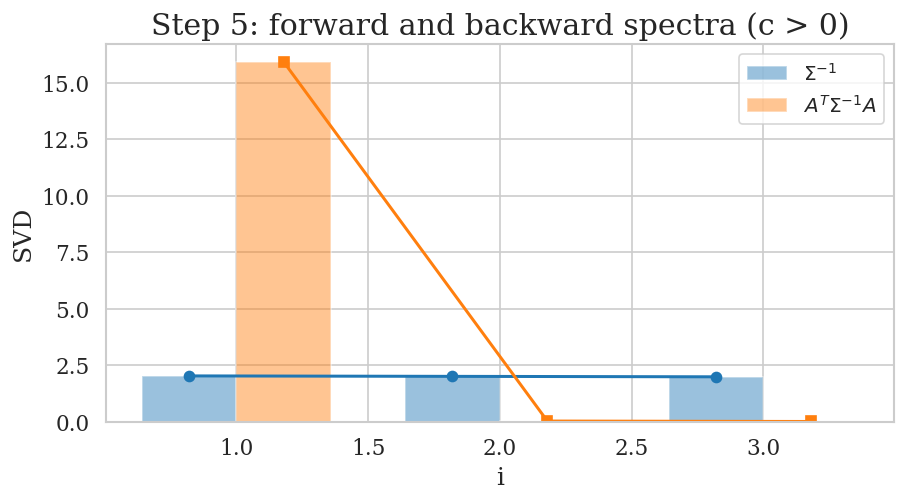

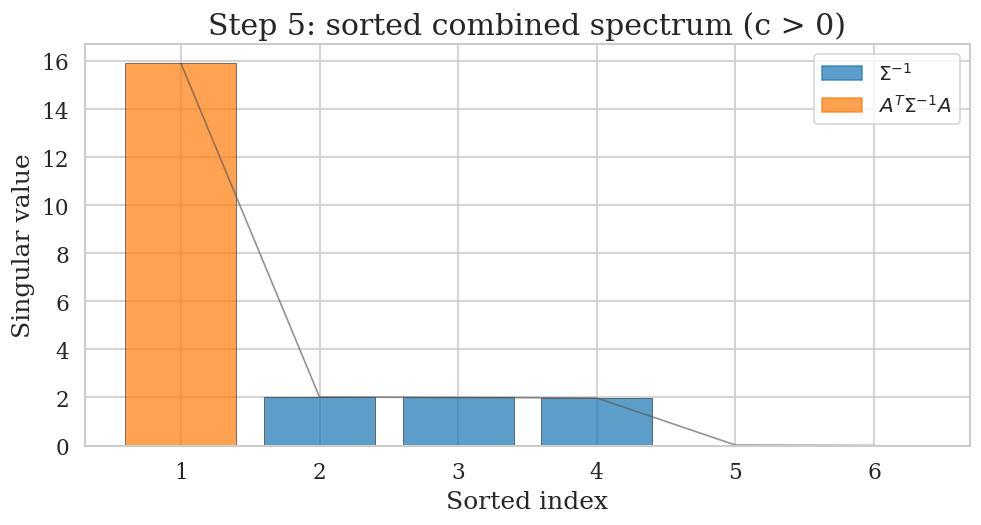

In [48]:
metrics_cpos_micro = compute_gis_metrics(A_cpos_micro, Sigma_cpos_micro, alpha=pipeline_cpos_config['alpha'], eps=pipeline_cpos_config['eps'])
ce_cpos = compute_ce_from_gis_metrics(metrics_cpos_micro, r_eps=None, eps=pipeline_cpos_config['eps'])

print(f"CE = {ce_cpos['CE']:.6f}")
plot_dual_gis_spectrum(metrics_cpos_micro['sv_forward'], metrics_cpos_micro['sv_backward'], 'Step 5: forward and backward spectra (c > 0)')
plot_sorted_combined_gis_spectrum(
    metrics_cpos_micro['sv_forward'],
    metrics_cpos_micro['sv_backward'],
    'Step 5: sorted combined spectrum (c > 0)',
)


### 5.6 Step 6 两步 SVD 构造粗粒化矩阵 W

第六步继续根据新的谱结构构造 `W`，并观察相关噪声是否改变了宏观方向的权重分配。


CE2 = 0.736241


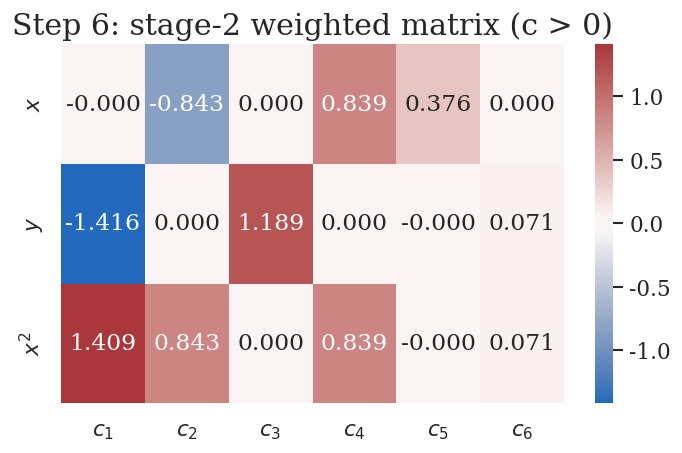

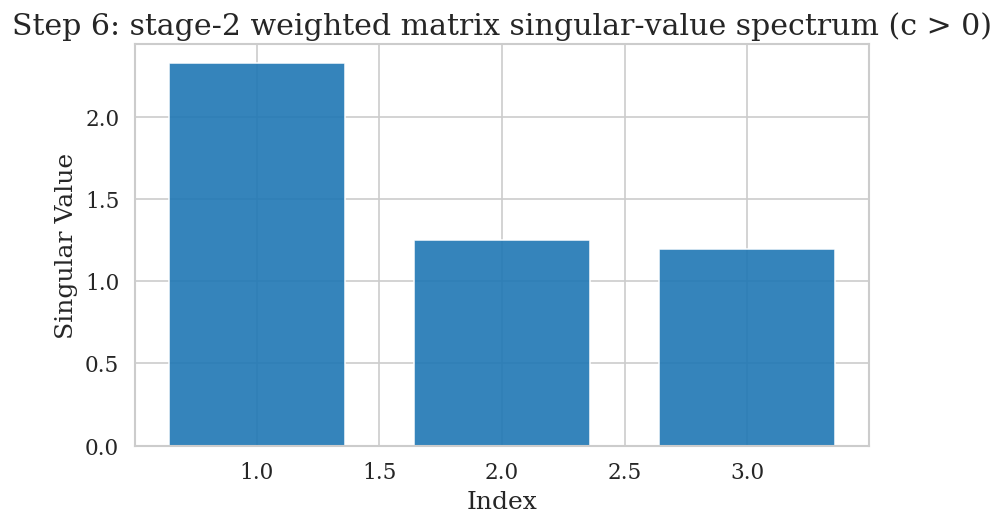

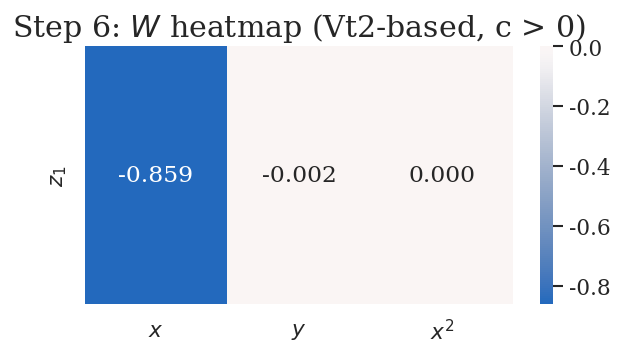

[[-8.59248668e-01 -2.07439955e-03  7.01722553e-05]]


In [49]:
W_pack_cpos = build_w_from_svd(
    A_cpos_micro,
    Sigma_cpos_micro,
    r=ce_cpos['selected_r'],
    alpha=pipeline_cpos_config['alpha'],
    eps=pipeline_cpos_config['eps'],
    mode='two_stage',
)
weighted_matrix_cpos = np.asarray(W_pack_cpos['basis_info']['weighted_matrix'], dtype=float)

# CHANGED: use Vt2[:, :r] instead of U2[:, :r], then transpose it back to the
# usual row-wise W shape. To restore the previous version, replace basis_cpos =
# Vt2_cpos[:, :W_pack_cpos['r']] with basis_cpos = U2_cpos[:, :W_pack_cpos['r']].
U2_cpos, stage2_sv_cpos, Vt2_cpos = np.linalg.svd(weighted_matrix_cpos, full_matrices=False)
basis_cpos = Vt2_cpos[:, :W_pack_cpos['r']]
W_cpos = basis_cpos.T
macro_names_cpos = [f'$z_{i+1}$' for i in range(W_pack_cpos['r'])]
ce2_cpos = np.mean(stage2_sv_cpos[:W_pack_cpos['r']]) - np.mean(stage2_sv_cpos)

print(f"CE2 = {ce2_cpos:.6f}")
plot_matrix_heatmap(
    weighted_matrix_cpos,
    'Step 6: stage-2 weighted matrix (c > 0)',
    FEATURE_NAMES,
    [f'$c_{i+1}$' for i in range(weighted_matrix_cpos.shape[1])],
    center=0.0,
    figsize=(6.0, 4.0),
    annot=True,
    decimals=3,
)
plot_blue_singular_value_bars(stage2_sv_cpos, 'Step 6: stage-2 weighted matrix singular-value spectrum (c > 0)')
plot_matrix_heatmap(
    W_cpos,
    'Step 6: $W$ heatmap (Vt2-based, c > 0)',
    macro_names_cpos,
    FEATURE_NAMES,
    center=0.0,
    figsize=(5.2, 3.2),
    cmap='vlag',
    annot=True,
    decimals=3,
)
print(W_cpos)


### 5.7 Step 7 构造宏观变量

第七步只负责由粗粒化矩阵构造宏观变量，也就是根据

$$
\mathbf{z}_t = W \mathbf{o}_t
$$

得到宏观时间序列。按照附录 D 的流程，这一步先完成变量构造本身，数据对比图留到下一步统一展示。


In [50]:
z_cpos = apply_coarse_graining(W_cpos, obs_cpos)
Z_now_cpos, Z_next_cpos = prepare_time_pairs(z_cpos, tau=pipeline_cpos_config['tau'], burn_in=0, stride=1)

print('Macro series shape:', z_cpos.shape)
display(pd.DataFrame(z_cpos[:5], columns=macro_names_cpos))


Macro series shape: (201, 1)


,$z_1$
0,-0.643982
1,-0.252083
2,0.935634
3,0.152833
4,-0.690680


### 5.8 Step 8 数据对比图

第八步集中展示数据对比图。这里主要看两类对比：

1. 宏观变量与观测变量的趋势对比。
2. 宏观变量与原始状态变量的趋势对比。

这一部分不再额外展示宏观层谱图，重点放在粗粒化后保留下来的时间结构。

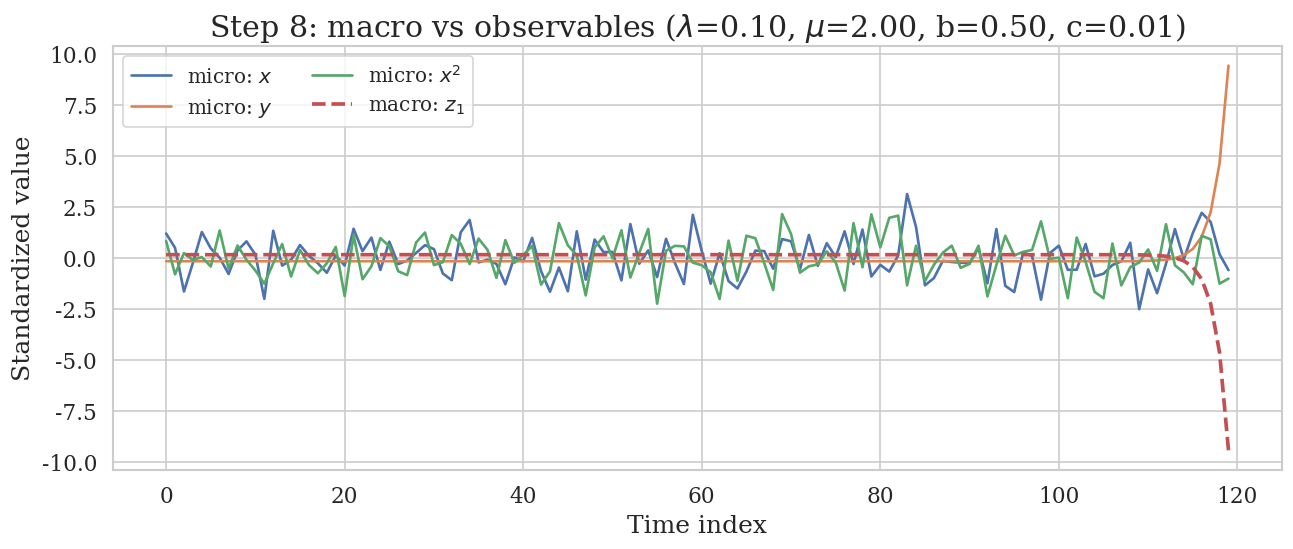

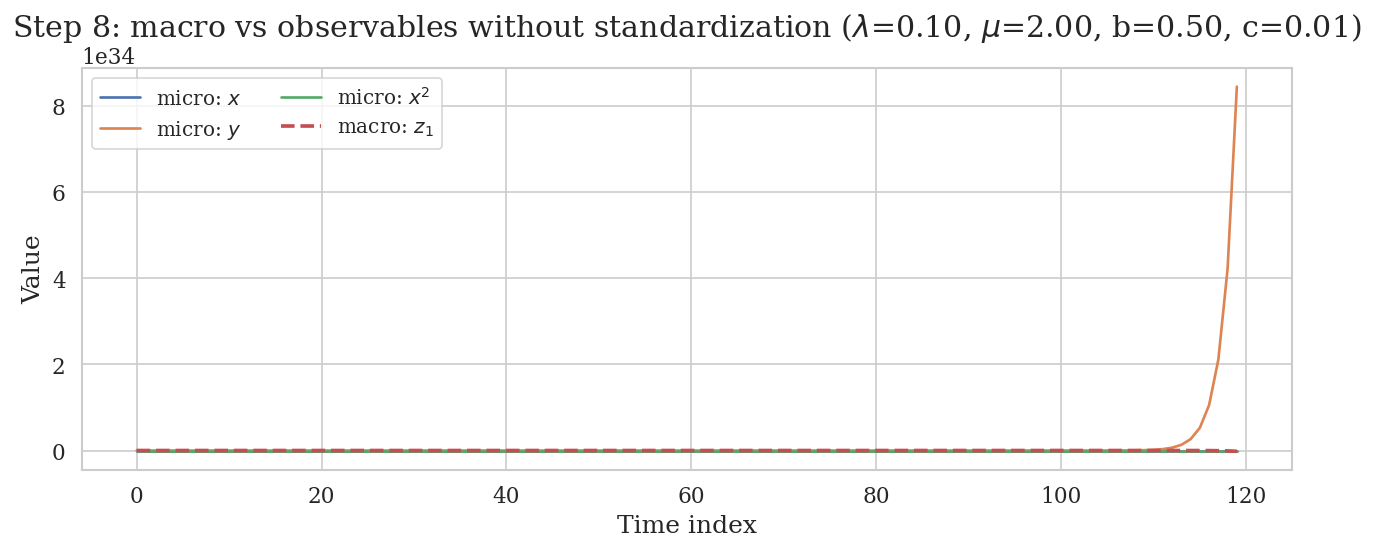

In [51]:
macro_pack_cpos = compute_macro_true_matrices(A_cpos_micro, Sigma_cpos_micro, W_cpos)
A_cpos_macro = macro_pack_cpos['A_macro']
Sigma_cpos_macro = macro_pack_cpos['Sigma_macro']
errors_cpos_macro = {}

plot_micro_macro_curves(
    obs_cpos,
    z_cpos,
    FEATURE_NAMES,
    macro_names_cpos,
    f'Step 8: macro vs observables ($\lambda$={pipeline_cpos_config["lam"]:.2f}, $\mu$={pipeline_cpos_config["mu"]:.2f}, b={pipeline_cpos_config["b"]:.2f}, c={pipeline_cpos_config["c"]:.2f})',
    n_plot=120,
)
plot_micro_macro_curves(
    obs_cpos,
    z_cpos,
    FEATURE_NAMES,
    macro_names_cpos,
    f'Step 8: macro vs observables without standardization ($\lambda$={pipeline_cpos_config["lam"]:.2f}, $\mu$={pipeline_cpos_config["mu"]:.2f}, b={pipeline_cpos_config["b"]:.2f}, c={pipeline_cpos_config["c"]:.2f})',
    n_plot=120,
    standardize=False,
)


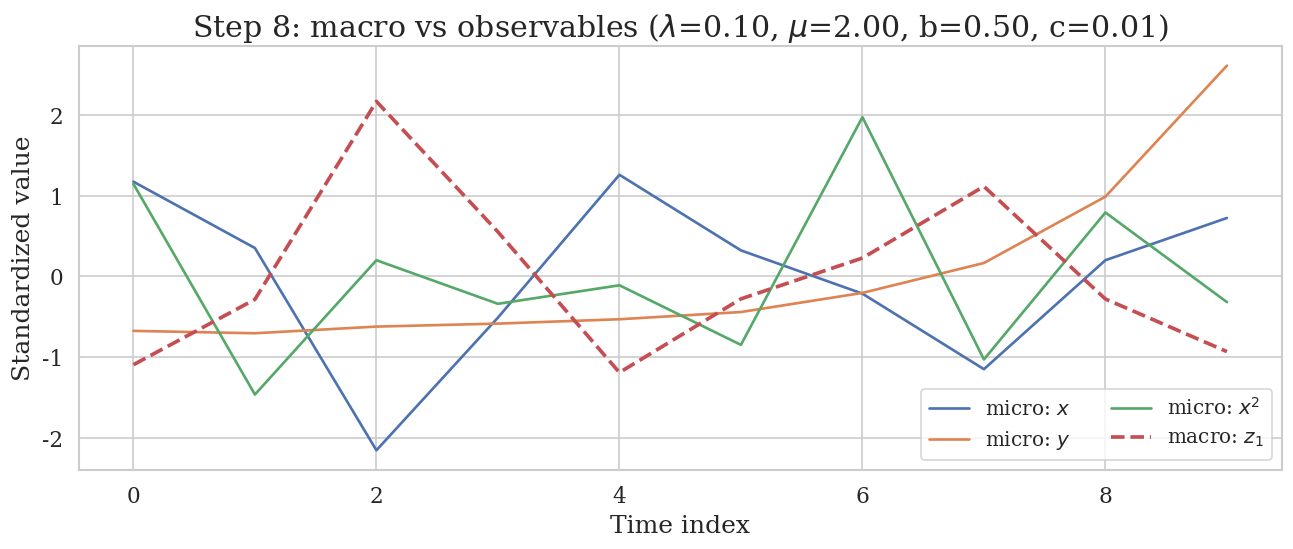

In [52]:
plot_micro_macro_curves(
    obs_cpos,
    z_cpos,
    FEATURE_NAMES,
    macro_names_cpos,
    f'Step 8: macro vs observables ($\lambda$={pipeline_cpos_config["lam"]:.2f}, $\mu$={pipeline_cpos_config["mu"]:.2f}, b={pipeline_cpos_config["b"]:.2f}, c={pipeline_cpos_config["c"]:.2f})',
    n_plot=10,
)

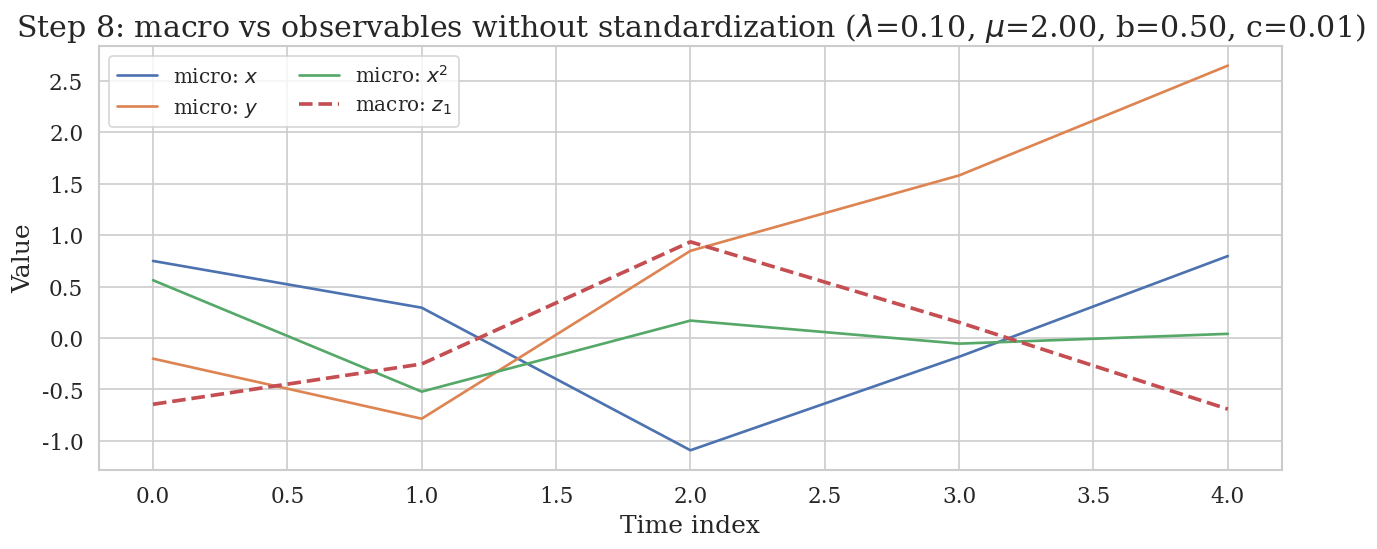

In [53]:
plot_micro_macro_curves(
    obs_cpos,
    z_cpos,
    FEATURE_NAMES,
    macro_names_cpos,
    f'Step 8: macro vs observables without standardization ($\lambda$={pipeline_cpos_config["lam"]:.2f}, $\mu$={pipeline_cpos_config["mu"]:.2f}, b={pipeline_cpos_config["b"]:.2f}, c={pipeline_cpos_config["c"]:.2f})',
    n_plot=5,
    standardize=False,
)

### 5.9 Step 9 结果汇总与结论

第九步将 `c > 0` 情形的关键指标整理成一张结果表，为最后一部分的总对比做准备。


In [54]:
summary_cpos = summarize_pipeline_for_display(
    label='c>0',
    config=pipeline_cpos_config,
    metrics_micro=metrics_cpos_micro,
    ce_result=ce_cpos,
    w_result=W_pack_cpos,
    macro_pack=macro_pack_cpos,
    errors_micro=errors_cpos_micro,
    errors_macro=errors_cpos_macro,
)
display(summary_cpos)


,label,lam,mu,b,c,selected_r,CE,gamma_hat,gamma_hat_eps,micro_J_alpha,micro_D,micro_N,stage2_sv1,stage2_sv2,micro_E1,macro_E1,micro_dim,macro_dim
0,c>0,0.1,2,0.5,0.005,1,1.556876,-0.689178,0.867698,-0.689178,2.079542,-10.349675,2.324709,1.247352,1.077125,None,3,1


## 6. 总结

最后将 `c = 0` 与 `c > 0` 两组完整流程实验的结果放在一起比较，重点回答三个问题：
1. 交叉相关噪声是否改变了 `CE` 的大小与符号。
2. 交叉相关噪声是否改变了两步 `SVD` 提取出的主方向与 `W` 的权重结构。
3. 交叉相关噪声进入后，宏观层是否仍然保留了微观层的主要趋势。


### 6.1 两类噪声结构的汇总对比

这一部分先给出统一汇总表，再分别从 `CE`、谱结构、粗粒化矩阵和预测误差四个角度做对比展示。


,label,lam,mu,b,c,selected_r,CE,gamma_hat,gamma_hat_eps,micro_J_alpha,micro_D,micro_N,stage2_sv1,stage2_sv2,micro_E1,macro_E1,micro_dim,macro_dim
0,c=0,0.3,0.7,0.6,0.000,1,0.625353,-0.406019,0.219334,-0.406019,1.532477,-6.404710,1.578644,1.295489,1.719372,None,3,1
1,c>0,0.1,2.0,0.5,0.005,1,1.556876,-0.689178,0.867698,-0.689178,2.079542,-10.349675,2.324709,1.247352,1.077125,None,3,1


C:\Users\Administrator.DESKTOP-BFUOLPM\AppData\Local\Temp\ipykernel_22024\2132266621.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_summary_df, x='label', y='CE', ax=axes[0], palette='Set2')
C:\Users\Administrator.DESKTOP-BFUOLPM\AppData\Local\Temp\ipykernel_22024\2132266621.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=final_summary_df, x='label', y='stage2_sv1', ax=axes[1], palette='Set2')


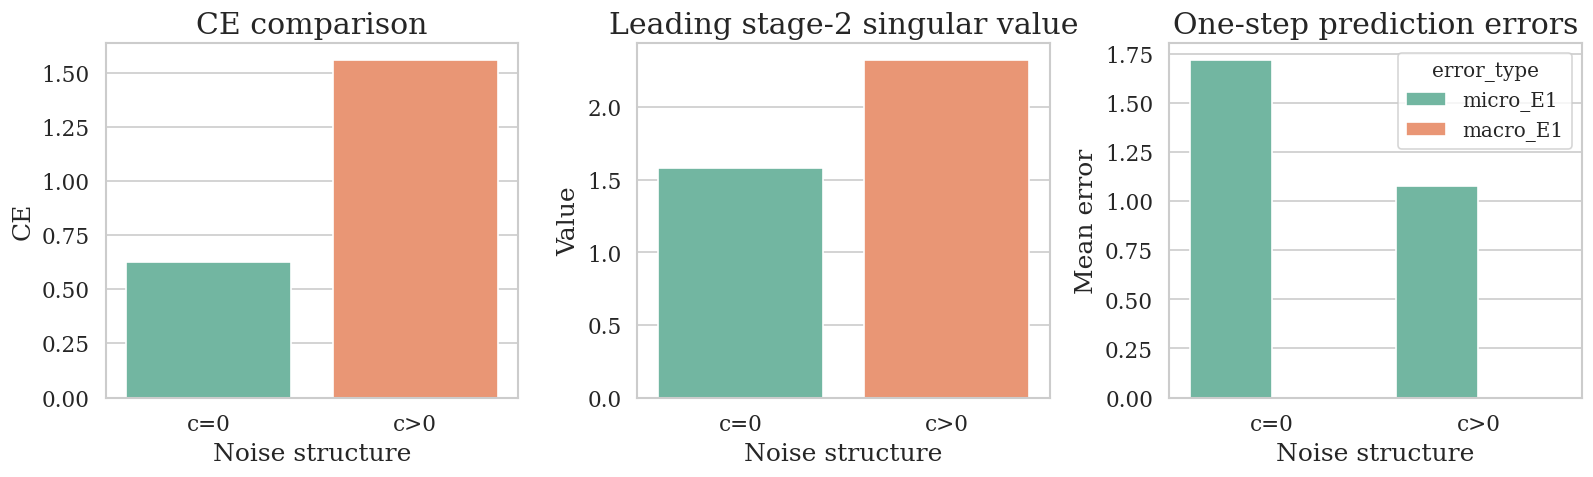

In [55]:
final_summary_df = pd.concat([summary_c0, summary_cpos], ignore_index=True)
display(final_summary_df)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

sns.barplot(data=final_summary_df, x='label', y='CE', ax=axes[0], palette='Set2')
axes[0].set_title('CE comparison')
axes[0].set_xlabel('Noise structure')
axes[0].set_ylabel('CE')

sns.barplot(data=final_summary_df, x='label', y='stage2_sv1', ax=axes[1], palette='Set2')
axes[1].set_title('Leading stage-2 singular value')
axes[1].set_xlabel('Noise structure')
axes[1].set_ylabel('Value')

error_compare_df = final_summary_df[['label', 'micro_E1', 'macro_E1']].melt(id_vars='label', var_name='error_type', value_name='mean_error')
sns.barplot(data=error_compare_df, x='label', y='mean_error', hue='error_type', ax=axes[2], palette='Set2')
axes[2].set_title('One-step prediction errors')
axes[2].set_xlabel('Noise structure')
axes[2].set_ylabel('Mean error')

plt.tight_layout()
plt.show()


### 6.2 本实验的结论性说明

从这一版解析实验出发，可以重点检查以下结论是否成立：
- `CE` 是否主要由微观层谱与截断维度决定，而不需要宏观重新拟合。
- 当 `c` 从 `0` 变为正值时，`\Sigma_o^{-1}` 与 `A_o^T \Sigma_o^{-1} A_o` 的主谱是否发生系统性变化。
- 两步 `SVD` 得到的 `W` 是否能够稳定保留主要动力学方向，以及这种稳定性在交叉相关噪声下是否下降。

如果这些现象在数值结果中得到支持，那么就说明研究流程 2.0 在该解析动力学上是自洽的，并且能够较清晰地区分“纯对角噪声”和“带相关项噪声”对粗粒化效果的影响。
